# R2D2 on Wind Speed Data - Spatial Dependency

### Set up: libraries and datasets

In [1]:
import sys
import os

sys.path.insert(0, '/userdata/yangmi/MasterThesis/SBCK-python')

import SBCK
from SBCK import CDFt, R2D2
print("SBCK loaded from:", SBCK.__file__)

SBCK loaded from: /userdata/yangmi/MasterThesis/SBCK-python/SBCK/__init__.py


In [2]:
import numpy       as np
import scipy.stats as sc
import scipy.interpolate
import os
import xarray as xr
import matplotlib.pyplot as plt
import windpowerlib
import glob
import cftime
import pandas as pd

In [3]:
# Note: Since this is a "train-period" file, we will use a SUBSET of it as X0 (Historical)
# and the FULL file (or a future subset) as X1 (Target to correct).

# =========================================================
# 1.Observation Data for SfcWind Only
# =========================================================
path_obs = "/r/scratch/groups/downscaling/cordex-ALPS-allyear/obs/sfcWind_day_EOBS_ALPS_cordexgrid_1971-2022.nc"
ds_obs_full = xr.open_dataset(path_obs)
var_obs_name = "sfcWind"
print(f"Target Variable in Obs: {var_obs_name}")
print(f"Obs Time Range:   {ds_obs_full.time.values[0]}  to  {ds_obs_full.time.values[-1]}")

# Define the Calibration Period
calib_start = "1980-01-01"
calib_end   = "2022-12-31"

# Slicing Calibration Period (Y0)
# This is our 'Truth' for the training period
Y0_da = ds_obs_full[var_obs_name].sel(time=slice(calib_start, calib_end))

# Stack Observations ( define the grid mask)
    # Check dims: usually ('time', 'y', 'x') or ('time', 'lat', 'lon')
if 'y' in Y0_da.dims and 'x' in Y0_da.dims:
    Y0_stack = Y0_da.stack(points=('y', 'x'))
else:
    Y0_stack = Y0_da.stack(points=('lat', 'lon'))

# Create the "Land Mask" from Obs
# Any point that is NaN in Obs (e.g., Ocean) must be ignored in Models
Y0_vals = Y0_stack.transpose('time', 'points').values
valid_mask = ~np.isnan(Y0_vals[0, :])
valid_indices = np.where(valid_mask)[0]

# Filter Y0 to valid points only
Y0_valid = Y0_vals[:, valid_indices]
print(f"   Mask defined: Keeping {len(valid_indices)} points (out of {Y0_vals.shape[1]})")

# Extract integer months (1-12) for E-OBS
months_Y0 = Y0_stack['time'].dt.month.values
years_Y0  = Y0_stack['time'].dt.year.values
print(f"   Extract month and year information from E-OBS: \n Month: {Y0_stack['time'].dt.month} of leangth {len(months_Y0)} \n Year: {Y0_stack['time'].dt.year}")


Target Variable in Obs: sfcWind
Obs Time Range:   1980-01-01T00:00:00.000000000  to  2022-12-31T00:00:00.000000000
   Mask defined: Keeping 12316 points (out of 16384)
   Extract month and year information from E-OBS: 
 Month: <xarray.DataArray 'month' (time: 15706)> Size: 126kB
array([ 1,  1,  1, ..., 12, 12, 12], shape=(15706,))
Coordinates:
  * time     (time) datetime64[ns] 126kB 1980-01-01 1980-01-02 ... 2022-12-31
Attributes:
    standard_name:  time
    long_name:      Time in days
    axis:           T of leangth 15706 
 Year: <xarray.DataArray 'year' (time: 15706)> Size: 126kB
array([1980, 1980, 1980, ..., 2022, 2022, 2022], shape=(15706,))
Coordinates:
  * time     (time) datetime64[ns] 126kB 1980-01-01 1980-01-02 ... 2022-12-31
Attributes:
    standard_name:  time
    long_name:      Time in days
    axis:           T


In [4]:
# Path to Model Data
# Define root paths
full_data_path = "/userdata/yangmi/MasterThesis/Data/Complete_RCMs"

# Define the path to RCM data

variable_name = "sfcWind" 

# Find all files for this variable
# This grabs both GCM and RCM files initially
file_pattern = os.path.join(full_data_path, f"{variable_name}_day_*.nc")
all_files = glob.glob(file_pattern)

print(f" Scanning {len(all_files)} files in {full_data_path}...")

# FILTER & ORGANIZE RCMs
rcm_datasets = {}

for file_path in all_files:
    filename = os.path.basename(file_path)
    parts = filename.split('_')
    
    # RCM filenames usually look like: 
    # sfcWind_day_EUR-11_ALADIN63_CNRM-CM5_r1i1p1_...
    # parts[2] is the Domain (EUR-11)
    
    if len(parts) > 2 and "EUR-11" in parts[2]:
        # It IS an RCM file!
        
        # Extract names to build a unique key
        domain   = parts[2]  # EUR-11
        rcm_model = parts[3] # e.g. ALADIN63
        driving_gcm = parts[4] # e.g. CNRM-CM5
        
        # Create a clean, unique ID for this simulation
        model_key = f"{rcm_model}_{driving_gcm}"
        
        try:
            # Load the dataset (Lazy load - doesn't eat RAM yet)
            ds = xr.open_dataset(file_path)
            
            # Store it in our dictionary
            rcm_datasets[model_key] = {
                "data": ds,
                "path": file_path,
                "rcm": rcm_model,
                "gcm": driving_gcm
            }
            
            print(f" Loaded RCM: {model_key}")
            
        except Exception as e:
            print(f" Error loading {filename}: {e}")
            
    else:
        # It is likely a GCM or Obs file -> Skip it
        # print(f"Start skipping {filename} (Not an RCM)")
        pass
 
print("\n" + "="*30)
print(f"Successfully imported {len(rcm_datasets)} RCM simulations.")
print("="*30)
print("Available Keys (use these to access specific models):")
for key in sorted(rcm_datasets.keys()):
    print(f"  {key}")


 Scanning 8 files in /userdata/yangmi/MasterThesis/Data/Complete_RCMs...
 Loaded RCM: CCLM4-8-17_MPI-ESM-LR
 Loaded RCM: RegCM4-6_MPI-ESM-LR
 Loaded RCM: ALADIN63_CNRM-CM5
 Loaded RCM: ALADIN63_MPI-ESM-LR
 Loaded RCM: CCLM4-8-17_CNRM-CM5
 Loaded RCM: RegCM4-6_CNRM-CM5
 Loaded RCM: CCLM4-8-17_MIROC5
 Loaded RCM: REMO2015_MIROC5

Successfully imported 8 RCM simulations.
Available Keys (use these to access specific models):
  ALADIN63_CNRM-CM5
  ALADIN63_MPI-ESM-LR
  CCLM4-8-17_CNRM-CM5
  CCLM4-8-17_MIROC5
  CCLM4-8-17_MPI-ESM-LR
  REMO2015_MIROC5
  RegCM4-6_CNRM-CM5
  RegCM4-6_MPI-ESM-LR


### Apply bias correction on each month's data, in each RCM

In climate science, applying bias correction on a monthly or seasonal basis is highly recommended—especially for wind. The atmospheric physics driving winter storms are completely different from summer thermal breezes, so a single, all-year R2D2 curve can sometimes "smear" these distinct seasonal distributions together.

Below code takes approximately 38 minutes (2 minutes longer than the monthly CDFt on entire time frame). 

In [52]:
import time
from joblib import Parallel, delayed

slice_hist_train = slice('1980-01-01', '2017-12-31')
slice_hist_test  = slice('2018-01-01', '2022-12-31')
slice_hist_full  = slice('1980-01-01', '2022-12-31') 

slice_fut_train  = slice('2023-01-01', '2094-12-31')
slice_fut_test   = slice('2095-01-01', '2099-12-31')
slice_fut_full   = slice('2023-01-01', '2099-12-31') 

def process_single_rcm_monthly(key, ds_rcm, Y0_stack, valid_indices, var_name):
    print(f"[{key}] Starting processing...")
    
    try:
        X_da = ds_rcm[var_name]
        try: 
            X_da.sel(time=slice_hist_train)
        except KeyError:
            X_da = X_da.convert_calendar('standard', align_on='year')
        
        X_da = X_da.sel(time=slice('1980-01-01', '2099-12-31'))
        
        dims = list(X_da.dims)
        if 'y' in dims and 'x' in dims:
            stack_coords = ('y', 'x')
        elif 'rlat' in dims and 'rlon' in dims:
            stack_coords = ('rlat', 'rlon')
        else:
            stack_coords = ('lat', 'lon')
            
        X_stack = X_da.stack(points=stack_coords)

        # Safety Check
        if Y0_stack.sizes['points'] != X_stack.sizes['points']:
            raise ValueError(f"GRID MISMATCH: Obs has {Y0_stack.sizes['points']} points, Model has {X_stack.sizes['points']}.")
        
        Y0_train_da = Y0_stack.sel(time=slice_hist_train)
        X0_train_da = X_stack.sel(time=slice_hist_train)
        X1_train_da = X_stack.sel(time=slice_fut_train)
        
        X0_full_da = X_stack.sel(time=slice_hist_full)
        X1_full_da = X_stack.sel(time=slice_fut_full)
        
        def get_masked_vals(da):
            return da.transpose('time', 'points').values[:, valid_indices]
            
        Y0_train = get_masked_vals(Y0_train_da)
        X0_train = get_masked_vals(X0_train_da)
        X1_train = get_masked_vals(X1_train_da)
        
        X0_full = get_masked_vals(X0_full_da)
        X1_full = get_masked_vals(X1_full_da)

        # X_master_vals: the entire RCM time frame.
        X_master_vals = X_stack.transpose('time', 'points').values
        Z_master_corrected = np.full((X_master_vals.shape[0], len(valid_indices)), np.nan)
        
        months_Y0_train = Y0_train_da['time'].dt.month.values
        months_X0_train = X0_train_da['time'].dt.month.values
        months_X1_train = X1_train_da['time'].dt.month.values
        
        months_X0_full = X0_full_da['time'].dt.month.values
        months_X1_full = X1_full_da['time'].dt.month.values
        months_master  = X_stack['time'].dt.month.values

        # We set a seed so the same 2 pixels are used for all months
        # np.random.seed(42) 
        # ref_idx = np.random.choice(len(valid_indices), size=2, replace=False).tolist()

        # ref_idx = [2581, 7036, 7201, 8545, 10543]
        #ref_idx = [498, 2581, 7201, 9768]
        ref_idx = [2581, 9768]
        print(f"[{key}] Selected Reference Indices: {ref_idx}")

        for month in range(1, 13):
            idx_Y0_tr = (months_Y0_train == month)
            idx_X0_tr = (months_X0_train == month)
            idx_X1_tr = (months_X1_train == month)
            
            Y0_m_tr = Y0_train[idx_Y0_tr, :]
            X0_m_tr = X0_train[idx_X0_tr, :]
            X1_m_tr = X1_train[idx_X1_tr, :]
            
            if len(Y0_m_tr) == 0 or len(X0_m_tr) == 0 or len(X1_m_tr) == 0:
                print(f"[{key}] Warning: Missing data for month {month}. Skipping...")
                continue
                
            print(f"Fitting {key} month {month} with R2D2...")
            bc = R2D2(refs=ref_idx, version=2)
            # refs     : list
			# Index of reference for SchaakeShuffleRef, see SBCK.tools.SchaakeShuffleRef

            bc.fit(Y0=Y0_m_tr, X0=X0_m_tr, X1=X1_m_tr)

            idx_X0_full = (months_X0_full == month)
            idx_X1_full = (months_X1_full == month)
            idx_master  = (months_master == month)
            
            X0_m_full = X0_full[idx_X0_full, :]
            X1_m_full = X1_full[idx_X1_full, :]

            print(f"Predicting {key} month {month} with R2D2...")
            # D. Predict over the continuous timeline
            Z1_m_full, Z0_m_full = bc.predict(X1=X1_m_full, X0=X0_m_full)

            # Because we passed 2 refs, Z1 and Z0 are now 3D arrays: (time, space, 2)
            # We average along the last axis to flatten them back to (time, space)
            if len(ref_idx) > 1:
                Z1_m_full = np.mean(Z1_m_full, axis=-1)
                Z0_m_full = np.mean(Z0_m_full, axis=-1)

            # Force positive
            Z1_m_full[Z1_m_full < 0] = 0
            Z0_m_full[Z0_m_full < 0] = 0

            # E. Stitch Historical and Future back together
            Z_m_combined = np.vstack((Z0_m_full, Z1_m_full))
            Z_master_corrected[idx_master, :] = Z_m_combined

        # --- 6. RECONSTRUCT SPATIAL MAP ---
        Z_full_spatial = np.full_like(X_master_vals, np.nan)
        Z_full_spatial[:, valid_indices] = Z_master_corrected
        
        ds_corrected = xr.DataArray(
            Z_full_spatial,
            coords=X_stack.coords,
            dims=X_stack.dims,
            name=var_name,
            attrs=ds_rcm[var_name].attrs
        ).unstack('points')

        ds_corrected.attrs['bias_correction'] = f'SBCK R2D2-CDFt v2 (train-test) | Refs: {ref_idx}'
        ds_out = ds_corrected.to_dataset(name=var_name)
        
        print(f"[{key}] Processing complete.")
        return (key, ds_out)

    except Exception as e:
        print(f"[{key}] ERROR: {e}")
        return (key, None)

1 or 2 reference points: takes 45 min approx. 

4 reference points: 50 mins approx. 

In [53]:
n_jobs = 16  # 8 CPUs (One for each model)
print(f"\nLaunching Parallel Processing on {n_jobs} CPUs...")
start_time = time.time()

# Configuration variables
tasks = []
var_name = "sfcWind"
for key, info in rcm_datasets.items():
    tasks.append(
        delayed(process_single_rcm_monthly)(
            key, 
            info['data'], 
            Y0_stack,      # We pass the full stacked Y0 to slice internally
            valid_indices, 
            var_name
        )
    )

# Execute Tasks
results_list = Parallel(n_jobs=n_jobs, verbose=10)(tasks)

# Rebuild Dictionary from Results
corrected_datasets = {}
for key, ds in results_list:
    if ds is not None:
        corrected_datasets[key] = ds

elapsed = (time.time() - start_time) / 60
print(f"\n Processed {len(corrected_datasets)} models in {elapsed:.1f} minutes.")


Launching Parallel Processing on 16 CPUs...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


[ALADIN63_CNRM-CM5] Starting processing...
[RegCM4-6_MPI-ESM-LR] Starting processing...
[CCLM4-8-17_MPI-ESM-LR] Starting processing...
[CCLM4-8-17_CNRM-CM5] Starting processing...
[ALADIN63_MPI-ESM-LR] Starting processing...
[RegCM4-6_CNRM-CM5] Starting processing...
[CCLM4-8-17_MIROC5] Starting processing...
[REMO2015_MIROC5] Starting processing...
[ALADIN63_MPI-ESM-LR] Selected Reference Indices: [2581, 9768]
[ALADIN63_CNRM-CM5] Selected Reference Indices: [2581, 9768]
[RegCM4-6_MPI-ESM-LR] Selected Reference Indices: [2581, 9768]
Fitting ALADIN63_MPI-ESM-LR month 1 with R2D2...
[CCLM4-8-17_MPI-ESM-LR] Selected Reference Indices: [2581, 9768]
Fitting ALADIN63_CNRM-CM5 month 1 with R2D2...
Fitting RegCM4-6_MPI-ESM-LR month 1 with R2D2...
[CCLM4-8-17_MIROC5] Selected Reference Indices: [2581, 9768]
Fitting CCLM4-8-17_MPI-ESM-LR month 1 with R2D2...
Fitting CCLM4-8-17_MIROC5 month 1 with R2D2...
[REMO2015_MIROC5] Selected Reference Indices: [2581, 9768]
[CCLM4-8-17_CNRM-CM5] Selected Re

[Parallel(n_jobs=16)]: Done 2 out of 8 | elapsed: 41.7min remaining: 125.0min


[CCLM4-8-17_MIROC5] Processing complete.
[CCLM4-8-17_CNRM-CM5] Processing complete.


...

[Parallel(n_jobs=16)]: Done 4 out of 8 | elapsed: 42.5min remaining: 42.5min
[Parallel(n_jobs=16)]: Done 5 out of 8 | elapsed: 42.6min remaining: 25.6min


Predicting ALADIN63_MPI-ESM-LR month 12 with R2D2...


[Parallel(n_jobs=16)]: Done 6 out of 8 | elapsed: 42.8min remaining: 14.3min


Predicting RegCM4-6_CNRM-CM5 month 12 with R2D2...
Current reference point = 2581.
Current reference point = 2581.
Current reference point = 9768.
Current reference point = 9768.
[RegCM4-6_CNRM-CM5] Processing complete.
[ALADIN63_MPI-ESM-LR] Processing complete.

 Processed 8 models in 44.7 minutes.


[Parallel(n_jobs=16)]: Done 8 out of 8 | elapsed: 44.7min finished


In [55]:
corrected_datasets.items()

dict_items([('CCLM4-8-17_MPI-ESM-LR', <xarray.Dataset> Size: 3GB
Dimensions:  (y: 128, x: 128, time: 43830)
Coordinates:
  * y        (y) float64 1kB -8.745 -8.635 -8.525 -8.415 ... 5.005 5.115 5.225
  * x        (x) float64 1kB -13.3 -13.2 -13.08 -12.97 ... 0.445 0.555 0.665
  * time     (time) datetime64[ns] 351kB 1980-01-01T12:00:00 ... 2099-12-31T1...
Data variables:
    sfcWind  (time, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan), ('RegCM4-6_MPI-ESM-LR', <xarray.Dataset> Size: 3GB
Dimensions:  (y: 128, x: 128, time: 43830)
Coordinates:
  * y        (y) float64 1kB -8.745 -8.635 -8.525 -8.415 ... 5.005 5.115 5.225
  * x        (x) float64 1kB -13.3 -13.2 -13.08 -12.97 ... 0.445 0.555 0.665
  * time     (time) datetime64[ns] 351kB 1980-01-01T12:00:00 ... 2099-12-31T1...
Data variables:
    sfcWind  (time, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan), ('ALADIN63_CNRM-CM5', <xarray.Dataset> Size: 3GB
Dimensions:  (y: 128, x: 128, time: 43830)
Coordinates:
 

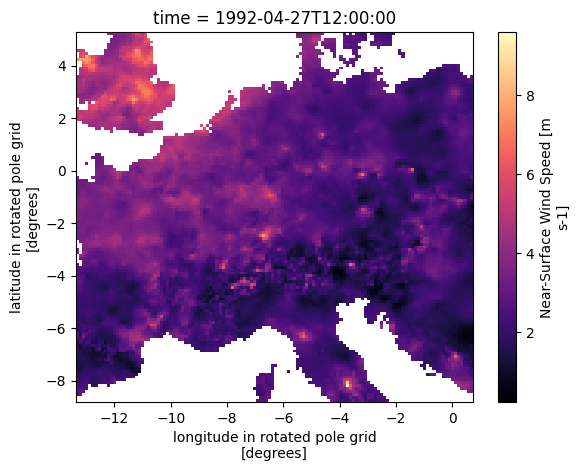

In [56]:
corrected_datasets['ALADIN63_CNRM-CM5']['sfcWind'].isel(time=4500).plot(cmap='magma')

Save the results.

In [57]:

save_path = "/userdata/yangmi/MasterThesis/Data"

if not os.path.exists(save_path):
    print(f"Creating directory: {save_path}")
    os.makedirs(save_path)
else:
    print(f"Directory exists: {save_path}")

print(f"\nSaving {len(corrected_datasets)} datasets...")

for key, ds in corrected_datasets.items():
    filename = f"sfcWind_R2D2-monthly-train-test_corrected_{key}.nc"
    full_path = os.path.join(save_path, filename)
    
    print(f"   Writing: {filename} ...")
    try:
        ds.to_netcdf(full_path)
        print(f"   Saved successfully.")
    except Exception as e:
        print(f"   Failed to save {key}: {e}")

Directory exists: /userdata/yangmi/MasterThesis/Data

Saving 8 datasets...
   Writing: sfcWind_R2D2-monthly-train-test_corrected_CCLM4-8-17_MPI-ESM-LR.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_RegCM4-6_MPI-ESM-LR.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_ALADIN63_CNRM-CM5.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_ALADIN63_MPI-ESM-LR.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_CCLM4-8-17_CNRM-CM5.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_RegCM4-6_CNRM-CM5.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_CCLM4-8-17_MIROC5.nc ...
   Saved successfully.
   Writing: sfcWind_R2D2-monthly-train-test_corrected_REMO2015_MIROC5.nc ...
   Saved successfully.


R2D2 Reference Coordinates:
Point 1 (Index 2581): Lon 8.634°, Lat 45.327°
Point 2 (Index 9768): Lon 6.784°, Lat 51.710°


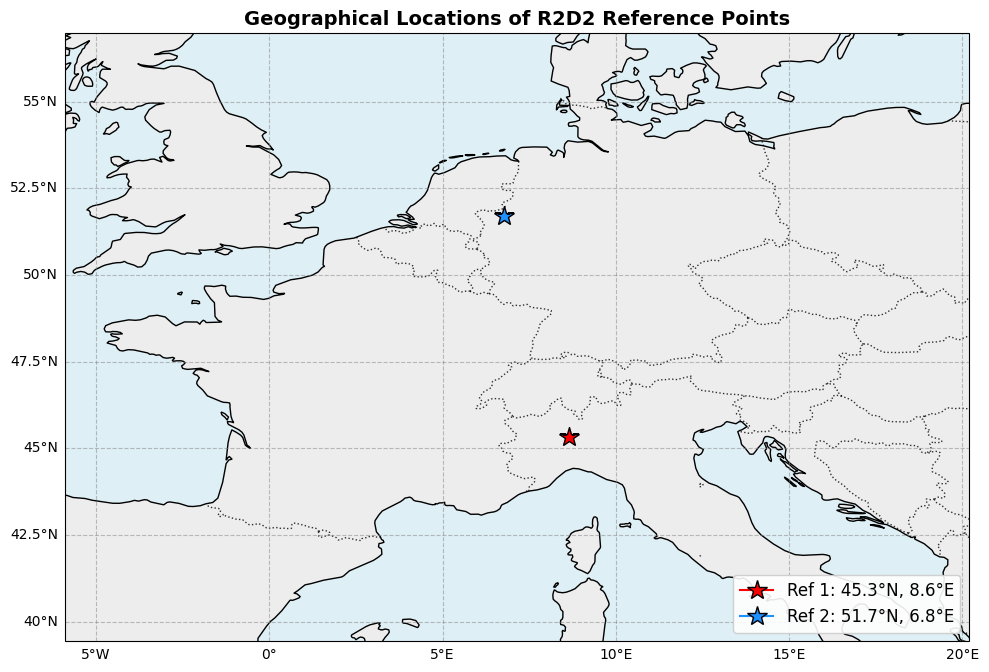

In [54]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


Y0_test = Y0_stack
Y0_test_vals = Y0_test.transpose('time', 'points').values

# Check what specific model uses for y/x names
dim_y = 'y' if 'y' in Y0_da.dims else 'rlat'
dim_x = 'x' if 'x' in Y0_da.dims else 'rlon'

# Get the exact grid dimensions (e.g., 128 x 128)
ny = Y0_da.sizes[dim_y]
nx = Y0_da.sizes[dim_x]

# Extract the 2D longitude and latitude arrays for Cartopy plotting
lons2d = Y0_da['lon'].values
lats2d = Y0_da['lat'].values

ref_idx = [2581, 9768]
#[498, 2581, 7201, 9768]
#[4281, 4010]
# 7036, 7201, 8545, 10543

flat_indices = valid_indices[ref_idx]

# Step B: Extract the coordinates using those flat indices
ref_lons = lons2d.flatten()[flat_indices]
ref_lats = lats2d.flatten()[flat_indices]

print("R2D2 Reference Coordinates:")
print(f"Point 1 (Index {ref_idx[0]}): Lon {ref_lons[0]:.3f}°, Lat {ref_lats[0]:.3f}°")
print(f"Point 2 (Index {ref_idx[1]}): Lon {ref_lons[1]:.3f}°, Lat {ref_lats[1]:.3f}°")

fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_title("Geographical Locations of R2D2 Reference Points", fontweight='bold', fontsize=14)

# Add basic geography for context
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.4)

# Add Gridlines
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False   
gl.right_labels = False 
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Zoom the map exactly to the borders of your 2D domain arrays
lon_min, lon_max = lons2d.min(), lons2d.max()
lat_min, lat_max = lats2d.min(), lats2d.max()
# Add a 1-degree buffer around the edges so the points aren't cut off
ax.set_extent([lon_min - 1, lon_max + 1, lat_min - 1, lat_max + 1], crs=ccrs.PlateCarree())

# Plot Point 1 (Red Star)
ax.plot(ref_lons[0], ref_lats[0], marker='*', color='red', markersize=15, 
        markeredgecolor='black', transform=ccrs.PlateCarree(), 
        label=f'Ref 1: {ref_lats[0]:.1f}°N, {ref_lons[0]:.1f}°E')

# Plot Point 2 (Blue Star)
ax.plot(ref_lons[1], ref_lats[1], marker='*', color='dodgerblue', markersize=15, 
        markeredgecolor='black', transform=ccrs.PlateCarree(), 
        label=f'Ref 2: {ref_lats[1]:.1f}°N, {ref_lons[1]:.1f}°E')

# ax.plot(ref_lons[2], ref_lats[2], marker='*', color='green', markersize=15, 
#         markeredgecolor='black', transform=ccrs.PlateCarree(), 
#         label=f'Ref 3: {ref_lats[2]:.1f}°N, {ref_lons[2]:.1f}°E')

# ax.plot(ref_lons[3], ref_lats[3], marker='*', color='orange', markersize=15, 
#         markeredgecolor='black', transform=ccrs.PlateCarree(), 
#         label=f'Ref 4: {ref_lats[3]:.1f}°N, {ref_lons[3]:.1f}°E')
# Add Legend
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

## Compare with CDFt 

#### Read data: CDFt and R2D2 monthly corrected

In [58]:
from pathlib import Path
input_dir = "/userdata/yangmi/MasterThesis/Data"

data_path = Path("/userdata/yangmi/MasterThesis/Data") 

variable_name = "sfcWind" 

# Find all files for this variable
# This grabs both GCM and RCM files initially
file_pattern = os.path.join(data_path, f"{variable_name}_R2D2-monthly-train-test_corrected_*.nc")
all_files = glob.glob(file_pattern)

print(f" Scanning {len(all_files)} files in {data_path}...")

# FILTER & ORGANIZE RCMs
R2D2_corrected = {}

for file_path in all_files:
    filename = os.path.basename(file_path)

    parts = filename.split('_')
    
    # RCM filenames usually look like: 
    # sfcWind_day_EUR-11_ALADIN63_CNRM-CM5_r1i1p1_...
    # parts[2] is the Domain (EUR-11)
    
    if len(parts) > 2:
        
        # Extract names to build a unique key
        BC_method   = "R2D2"
        rcm_model = parts[3] # e.g. ALADIN63
        driving_gcm = parts[4].replace(".nc", "") # e.g. CNRM-CM5
        
        # Create a clean, unique ID for this simulation
        model_key = f"{BC_method}_{rcm_model}_{driving_gcm}"
        model_key = model_key.replace(".nc", "")
        
        try:
            # Load the dataset (Lazy load - doesn't eat RAM yet)
            ds = xr.open_dataset(file_path)
            
            # Store it in our dictionary
            R2D2_corrected[model_key] = {
                "data": ds,
                "path": file_path,
                "rcm": rcm_model,
                "gcm": driving_gcm
            }
            
            print(f" Loaded RCM: {model_key}")
            
        except Exception as e:
            print(f" Error loading {filename}: {e}")
            
    else:
        pass

print("\n" + "="*30)
print(f"Successfully imported {len(R2D2_corrected)} RCM corrected datasets.")
print("="*30)
print("Available Keys (use these to access specific models):")
for key in sorted(R2D2_corrected.keys()):
    print(f"  {key}")

 Scanning 8 files in /userdata/yangmi/MasterThesis/Data...
 Loaded RCM: R2D2_ALADIN63_MPI-ESM-LR
 Loaded RCM: R2D2_CCLM4-8-17_CNRM-CM5
 Loaded RCM: R2D2_CCLM4-8-17_MPI-ESM-LR
 Loaded RCM: R2D2_REMO2015_MIROC5
 Loaded RCM: R2D2_RegCM4-6_MPI-ESM-LR
 Loaded RCM: R2D2_ALADIN63_CNRM-CM5
 Loaded RCM: R2D2_RegCM4-6_CNRM-CM5
 Loaded RCM: R2D2_CCLM4-8-17_MIROC5

Successfully imported 8 RCM corrected datasets.
Available Keys (use these to access specific models):
  R2D2_ALADIN63_CNRM-CM5
  R2D2_ALADIN63_MPI-ESM-LR
  R2D2_CCLM4-8-17_CNRM-CM5
  R2D2_CCLM4-8-17_MIROC5
  R2D2_CCLM4-8-17_MPI-ESM-LR
  R2D2_REMO2015_MIROC5
  R2D2_RegCM4-6_CNRM-CM5
  R2D2_RegCM4-6_MPI-ESM-LR


In [59]:

data_path = Path("/userdata/yangmi/MasterThesis/Data") 

variable_name = "sfcWind" 

# Find all files for this variable
# This grabs both GCM and RCM files initially
file_pattern = os.path.join(data_path, f"{variable_name}_CDFt-monthly-train-test_corrected_*.nc")
all_files = glob.glob(file_pattern)

print(f" Scanning {len(all_files)} files in {data_path}...")

# FILTER & ORGANIZE RCMs
CDFt_corrected = {}

for file_path in all_files:
    filename = os.path.basename(file_path)

    parts = filename.split('_')
    
    # RCM filenames usually look like: 
    # sfcWind_day_EUR-11_ALADIN63_CNRM-CM5_r1i1p1_...
    # parts[2] is the Domain (EUR-11)
    
    if len(parts) > 2:
        
        # Extract names to build a unique key
        BC_method   = "CDFt"
        rcm_model = parts[3] # e.g. ALADIN63
        driving_gcm = parts[4].replace(".nc", "") # e.g. CNRM-CM5
        
        # Create a clean, unique ID for this simulation
        model_key = f"{BC_method}_{rcm_model}_{driving_gcm}"
        model_key = model_key.replace(".nc", "")
        
        try:
            # Load the dataset (Lazy load - doesn't eat RAM yet)
            ds = xr.open_dataset(file_path)
            
            # Store it in our dictionary
            CDFt_corrected[model_key] = {
                "data": ds,
                "path": file_path,
                "rcm": rcm_model,
                "gcm": driving_gcm
            }
            
            print(f"Loaded RCM: {model_key}")
            
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            
    else:
        pass

print("\n" + "="*30)
print(f"Successfully imported {len(CDFt_corrected)} RCM corrected datasets.")
print("="*30)
print("Available Keys (use these to access specific models):")
for key in sorted(CDFt_corrected.keys()):
    print(f"  {key}")

 Scanning 8 files in /userdata/yangmi/MasterThesis/Data...
Loaded RCM: CDFt_REMO2015_MIROC5
Loaded RCM: CDFt_RegCM4-6_CNRM-CM5
Loaded RCM: CDFt_CCLM4-8-17_CNRM-CM5
Loaded RCM: CDFt_ALADIN63_MPI-ESM-LR
Loaded RCM: CDFt_ALADIN63_CNRM-CM5
Loaded RCM: CDFt_RegCM4-6_MPI-ESM-LR
Loaded RCM: CDFt_CCLM4-8-17_MPI-ESM-LR
Loaded RCM: CDFt_CCLM4-8-17_MIROC5

Successfully imported 8 RCM corrected datasets.
Available Keys (use these to access specific models):
  CDFt_ALADIN63_CNRM-CM5
  CDFt_ALADIN63_MPI-ESM-LR
  CDFt_CCLM4-8-17_CNRM-CM5
  CDFt_CCLM4-8-17_MIROC5
  CDFt_CCLM4-8-17_MPI-ESM-LR
  CDFt_REMO2015_MIROC5
  CDFt_RegCM4-6_CNRM-CM5
  CDFt_RegCM4-6_MPI-ESM-LR


In [60]:
CDFt_corrected['CDFt_REMO2015_MIROC5']['data']['sfcWind']

<xarray.DataArray 'sfcWind' (time: 43800, y: 128, x: 128)> Size: 3GB
[717619200 values with dtype=float32]
Coordinates:
  * time     (time) object 350kB 1980-01-01 12:00:00 ... 2099-12-31 12:00:00
  * y        (y) int64 1kB 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * x        (x) int64 1kB 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
    lon      (y, x) float64 131kB ...
    lat      (y, x) float64 131kB ...
    height   float64 8B ...
Attributes:
    standard_name:     wind_speed
    long_name:         Near-Surface Wind Speed
    units:             m s-1
    comment:           near-surface (usually, 10 meters) wind speed.
    cell_methods:      time: mean
    history:           2017-02-27T13:47:53Z altered by CMOR: Treated scalar d...
    associated_files:  gridspecFile: gridspec_atmos_fx_GERICS-REMO2015_histor...
    bias_correction:   SBCK CDFt v2 (train-test)

In [61]:
R2D2_corrected['R2D2_REMO2015_MIROC5']['data']['sfcWind']

<xarray.DataArray 'sfcWind' (time: 43800, y: 128, x: 128)> Size: 3GB
[717619200 values with dtype=float32]
Coordinates:
  * time     (time) object 350kB 1980-01-01 12:00:00 ... 2099-12-31 12:00:00
  * y        (y) int64 1kB 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * x        (x) int64 1kB 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
    lon      (y, x) float64 131kB ...
    lat      (y, x) float64 131kB ...
    height   float64 8B ...
Attributes:
    standard_name:     wind_speed
    long_name:         Near-Surface Wind Speed
    units:             m s-1
    comment:           near-surface (usually, 10 meters) wind speed.
    cell_methods:      time: mean
    history:           2017-02-27T13:47:53Z altered by CMOR: Treated scalar d...
    associated_files:  gridspecFile: gridspec_atmos_fx_GERICS-REMO2015_histor...
    bias_correction:   SBCK R2D2-CDFt v2 (train-test) | Refs: [2581, 9768]

### Spatial Dependency Structure

#### 1. Spearman Rank Correlation with one anchor point

Unlike Pearson correlation, which evaluates the linear relationship between raw values (e.g., wind speeds of 15 m/s vs 12 m/s), Spearman Rank Correlation ($\rho$) evaluates the monotonic relationship by converting all raw data into ranks before calculating the correlation. 

Mathematically, for a given reference pixel $X$ and a target map pixel $Y$ over $n$ time steps, the algorithm does the following:

Step 1: Rank the data

Every time step is assigned a rank based on its value relative to the rest of the time series. The smallest wind speed gets rank 1, the highest gets rank $n$.

$R(X_i) = \text{Rank of } X \text{ at time } i$,

$R(Y_i) = \text{Rank of } Y \text{ at time } i$.

Step 2: Calculate the Pearson correlation of the ranks

The standard covariance and standard deviation equations are then applied strictly to the ranks:
$$\rho = \frac{\sum_{i=1}^{n} (R(X_i) - \overline{R(X)})(R(Y_i) - \overline{R(Y)})}{\sqrt{\sum_{i=1}^{n} (R(X_i) - \overline{R(X)})^2} \sqrt{\sum_{i=1}^{n} (R(Y_i) - \overline{R(Y)})^2}}$$

Where:$\overline{R(X)}$ and $\overline{R(Y)}$ are the mean of the ranks.

The numerator is the covariance of the ranks.The denominator is the product of the standard deviations of the ranks.Because R2D2 works specifically by reordering ranks to match historical spatial patterns, evaluating it using Spearman rank correlation is the theoretically perfect way to measure its success.

Critical Analysis: The Problem with the "Anchor Point" Map

- Local Bias (The "Egocentric" View): An anchor map only evaluates the spatial structure from the perspective of one single pixel. If the chosen center pixel happens to sit on a high mountain peak, its correlation map will reflect altitude-driven dynamics. 

- Failure to Quantify Distance-Decay: The fundamental law of atmospheric physics is that weather systems have a specific spatial scale (e.g., a storm front is usually a certain number of kilometers wide). Therefore, spatial correlation naturally decays as physical distance increases. An anchor map visualizes this vaguely as colors fading out, but it does not rigorously quantify the rate of that decay.

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
import cartopy.crs as ccrs
import cartopy.feature as cfeature

test_slice = slice('2018-01-01', '2022-12-31')

def vectorized_spearman(ref_ts, map_ts):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        # Convert to Ranks
        ref_ranks = stats.rankdata(ref_ts)
        map_ranks = stats.rankdata(map_ts, axis=0)
        
        # Center the ranks
        ref_c = ref_ranks - np.nanmean(ref_ranks)
        map_c = map_ranks - np.nanmean(map_ranks, axis=0)
        
        # Calculate Covariance and Std Dev
        cov = np.nansum(ref_c[:, None] * map_c, axis=0)
        std_ref = np.sqrt(np.nansum(ref_c**2))
        std_map = np.sqrt(np.nansum(map_c**2, axis=0))
        
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = cov / (std_ref * std_map)
        
    ocean_mask = np.isnan(map_ts).all(axis=0)
    corr[ocean_mask] = np.nan
    
    return corr

print("Calculating Observed Spatial Correlation (Spearman) for Test Period...")

Y0_test = Y0_stack.sel(time=test_slice)
Y0_test_vals = Y0_test.transpose('time', 'points').values

anchor_idx = valid_indices[len(valid_indices) // 2]
obs_anchor_ts = Y0_test_vals[:, anchor_idx]

obs_corr_map_flat = vectorized_spearman(obs_anchor_ts, Y0_test_vals)

# Check what specific model uses for y/x names
dim_y = 'y' if 'y' in Y0_da.dims else 'rlat'
dim_x = 'x' if 'x' in Y0_da.dims else 'rlon'

# Get the exact grid dimensions (e.g., 128 x 128)
ny = Y0_da.sizes[dim_y]
nx = Y0_da.sizes[dim_x]

# Force the 1D array back into the 2D grid shape mathematically
obs_corr_2d = obs_corr_map_flat.reshape(ny, nx)

# Extract the 2D longitude and latitude arrays for Cartopy plotting
lons2d = Y0_da['lon'].values
lats2d = Y0_da['lat'].values

anchor_y_idx = anchor_idx // nx
anchor_x_idx = anchor_idx % nx
anchor_lon = lons2d[anchor_y_idx, anchor_x_idx]
anchor_lat = lats2d[anchor_y_idx, anchor_x_idx]

r2d2_key = list(R2D2_corrected.keys())[0]  
base_key = r2d2_key.replace("R2D2_","")
cdft_key = f'CDFt_{base_key}' 
print(f"Comparing Base Model: {base_key}")

ds_cdft = CDFt_corrected[cdft_key]['data']['sfcWind']
ds_r2d2 = R2D2_corrected[r2d2_key]['data']['sfcWind'] 

datasets_to_test = {
    "1D CDF-t": ds_cdft,
    "Multivariate R2D2": ds_r2d2
}

results_corr = {}

# for name, ds in datasets_to_test.items():
#     print(f"Calculating {name} spatial correlation...")
    
#     ds_test = ds.sel(time=test_slice)
    
#     if dim_y in ds_test.dims:
#         ds_test_stack = ds_test.stack(points=(dim_y, dim_x))
#     else:
#         ds_test_stack = ds_test.stack(points=('rlat', 'rlon'))
        
#     ds_test_vals = ds_test_stack.transpose('time', 'points').values
    
#     model_anchor_ts = ds_test_vals[:, anchor_idx]
#     model_corr_flat = vectorized_spearman(model_anchor_ts, ds_test_vals)
    
#     valid_corr_mask = ~np.isnan(obs_corr_map_flat) & ~np.isnan(model_corr_flat)
#     rmse_corr = np.sqrt(np.mean((model_corr_flat[valid_corr_mask] - obs_corr_map_flat[valid_corr_mask])**2))
    
#     # Force reshape back to 2D
#     model_corr_2d = model_corr_flat.reshape(ny, nx)
    
#     results_corr[name] = {
#         "map_2d": model_corr_2d,
#         "rmse": rmse_corr
#     }

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Extract 2D arrays for math
cdft_corr_2d = results_corr["1D CDF-t"]["map_2d"]
r2d2_corr_2d = results_corr["Multivariate R2D2"]["map_2d"]

# Calculate the difference matrices
diff_cdft = cdft_corr_2d - obs_corr_2d
diff_r2d2 = r2d2_corr_2d - obs_corr_2d

# Calculate Absolute Improvement
# Negative means R2D2 is closer to Obs (Better). Positive means CDF-t is closer to Obs (Worse).
diff_improvement = np.abs(diff_r2d2) - np.abs(diff_cdft)


proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': proj})

# Formatting helper function to add geography and Lat/Lon labels
def format_map(ax, title):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.coastlines(resolution='50m', color='black', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.8)
    
    # Add the Star
    ax.plot(anchor_lon, anchor_lat, marker='*', color='gold', markersize=8, markeredgecolor='black', transform=ccrs.PlateCarree())
    
    # Add Gridlines and Labels (Cartopy)
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = False   # Hide top labels
    gl.right_labels = False # Hide right labels
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

cmap_corr = 'RdBu_r'
vmin_corr, vmax_corr = -0.2, 1.0  

im1 = axes[0, 0].pcolormesh(lons2d, lats2d, obs_corr_2d, cmap=cmap_corr, vmin=vmin_corr, vmax=vmax_corr, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[0, 0], "E-OBS (Truth)\nSpatial Correlation")

cdft_rmse = results_corr["1D CDF-t"]["rmse"]
axes[0, 1].pcolormesh(lons2d, lats2d, cdft_corr_2d, cmap=cmap_corr, vmin=vmin_corr, vmax=vmax_corr, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[0, 1], f"CDF-t\nRMSE: {cdft_rmse:.3f}")

r2d2_rmse = results_corr["Multivariate R2D2"]["rmse"]
axes[0, 2].pcolormesh(lons2d, lats2d, r2d2_corr_2d, cmap=cmap_corr, vmin=vmin_corr, vmax=vmax_corr, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[0, 2], f"R2D2\nRMSE: {r2d2_rmse:.3f}")

# Colorbar for Row 1 (Right Side)
cbar_ax1 = fig.add_axes([0.92, 0.55, 0.015, 0.3])
fig.colorbar(im1, cax=cbar_ax1, orientation='vertical', label='Spearman Correlation (ρ)')

# For differences (Centered at 0)
cmap_diff = 'RdBu_r'
vmin_diff, vmax_diff = -0.5, 0.5  

# We use PiYG for improvement: Green (Negative) = R2D2 Better. Pink (Positive) = CDFt Better.
cmap_imp = 'PiYG_r' 
vmin_imp, vmax_imp = -0.3, 0.3 

# Plot CDF-t Bias
im2 = axes[1, 0].pcolormesh(lons2d, lats2d, diff_cdft, cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[1, 0], "CDF-t Bias\n(CDFt - EOBS)")

# Plot R2D2 Bias
axes[1, 1].pcolormesh(lons2d, lats2d, diff_r2d2, cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[1, 1], "R2D2 Bias\n(R2D2 - EOBS)")

# Plot Absolute Improvement
im3 = axes[1, 2].pcolormesh(lons2d, lats2d, diff_improvement, cmap=cmap_imp, vmin=vmin_imp, vmax=vmax_imp, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[1, 2], "Improvement Map\n|R2D2 Bias| - |CDFt Bias|")

# Colorbar for Row 2, Plots 1 & 2 (Biases)
cbar_ax2 = fig.add_axes([0.15, 0.05, 0.35, 0.02])
fig.colorbar(im2, cax=cbar_ax2, orientation='horizontal', label='Bias in Correlation (Bias corrected - Obs)')

# Colorbar for Row 2, Plot 3 (Improvement)
cbar_ax3 = fig.add_axes([0.65, 0.05, 0.25, 0.02])
cbar_imp = fig.colorbar(im3, cax=cbar_ax3, orientation='horizontal', label='Difference in Absolute Error')
cbar_imp.set_ticks([vmin_imp, 0, vmax_imp])
cbar_imp.set_ticklabels(['R2D2 Better', '0', 'CDFt Better']) # Friendly labels!

# Final Spacing
plt.suptitle(f"Spatial Dependency Preservation: Spearman Correlation\nTest Period: 2018-2022 | Anchor Point marked by Star", fontsize=16, y=1.02)
plt.subplots_adjust(left=0.05, right=0.90, top=0.90, bottom=0.12, wspace=0.15, hspace=0.25)
plt.show()

Calculating Observed Spatial Correlation (Spearman) for Test Period...
Comparing Base Model: ALADIN63_MPI-ESM-LR


KeyError: '1D CDF-t'

#### 2. Correlograms (ideas from vrac 2018 Figure 5)

A Correlogram completely removes the "anchor point" bias. Here is how it works:

The algorithm **randomly selects** hundreds of grid cells across the entire domain.

- It pairs every single cell with every other cell, creating hundreds of thousands of unique station pairs.

- It calculates the physical geographic distance (in kilometers) between each pair.

- It calculates the Spearman rank correlation of the time series between each pair.

- It plots Distance on the X-axis against Correlation on the Y-axis.

- It provides a global assessment. It proves mathematically that regardless of where two points are located on the map, the bias correction method successfully reconstructed the exact physical distance-decay relationship observed in the historical climate records.

Some details:

The X-axis requires the physical distance in kilometers between every single station pair. Because the Earth is a sphere, we cannot use simple Pythagorean geometry (straight lines). We must use the Haversine Formula, which calculates the "great-circle" distance over a curved surface.

Spearman Rank Correlation is literally just the standard Pearson correlation applied to ranks instead of raw numbers.

In [62]:
import os
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings

def haversine_matrix(lons, lats):
    """Calculates the great-circle distance matrix (in km) between all point pairs."""
    lon_rad = np.radians(lons)
    lat_rad = np.radians(lats)
    
    dlon = lon_rad[:, None] - lon_rad[None, :]
    dlat = lat_rad[:, None] - lat_rad[None, :]
    
    a = np.sin(dlat / 2)**2 + np.cos(lat_rad[:, None]) * np.cos(lat_rad[None, :]) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return 6371.0 * c 

def get_pairwise_spearman(ts_array, triu_idx):
    """Calculates Spearman rank correlation for the specific upper-triangle pairs."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        ranks = stats.rankdata(ts_array, axis=0)
        corr_matrix = np.corrcoef(ranks.T).astype(np.float32)
    return corr_matrix[triu_idx]

def extract_ts(da, idx_list):
    """Safely stacks the DataArray and extracts the specified 1000 point indices."""
    dim_y = 'y' if 'y' in da.dims else 'rlat'
    dim_x = 'x' if 'x' in da.dims else 'rlon'
    stacked = da.stack(points=(dim_y, dim_x))
    return stacked.transpose('time', 'points').values[:, idx_list]

def prepare_baseline_correlogram(valid_indices, lats2d, lons2d, Y0_test_vals, n_points=1000):
    """Samples points, builds the distance matrix, and calculates Obs correlation."""
    print(f"  -> Randomly sampling {n_points} pixels...")
    np.random.seed(42) # Lock seed for reproducibility across runs
    n_samples = min(n_points, len(valid_indices))
    sample_idx = np.random.choice(valid_indices, size=n_samples, replace=False)

    lats_flat = lats2d.flatten()[sample_idx]
    lons_flat = lons2d.flatten()[sample_idx]

    print("  -> Calculating Haversine distance matrix...")
    dist_matrix = haversine_matrix(lons_flat, lats_flat)
    triu_indices = np.triu_indices(n_samples, k=1)
    distances_1d = dist_matrix[triu_indices]

    print("  -> Calculating Observation pairwise correlations...")
    obs_ts_sampled = Y0_test_vals[:, sample_idx]
    obs_corr_1d = get_pairwise_spearman(obs_ts_sampled, triu_indices)

    return sample_idx, triu_indices, distances_1d, obs_corr_1d

def plot_and_save_correlogram(distances_1d, obs_corr_1d, cdft_corr_1d, r2d2_corr_1d, base_key, save_dir, bin_width=25):
    """Bins the distances and generates the line plot."""
    print(f"    -> Binning data (width={bin_width}km) and generating plot...")
    
    max_dist = np.max(distances_1d)
    bins = np.arange(0, max_dist + bin_width, bin_width)
    bin_centers = bins[:-1] + (bin_width / 2)

    obs_binned  = np.zeros_like(bin_centers)
    cdft_binned = np.zeros_like(bin_centers)
    r2d2_binned = np.zeros_like(bin_centers)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        for i in range(len(bins)-1):
            mask = (distances_1d >= bins[i]) & (distances_1d < bins[i+1])
            if np.any(mask):
                obs_binned[i]  = np.nanmean(obs_corr_1d[mask])
                cdft_binned[i] = np.nanmean(cdft_corr_1d[mask])
                r2d2_binned[i] = np.nanmean(r2d2_corr_1d[mask])
            else:
                obs_binned[i] = cdft_binned[i] = r2d2_binned[i] = np.nan

    # PLOTTING
    fig = plt.figure(figsize=(10, 6))
    
    plt.plot(bin_centers, obs_binned,  'o-', color='black', label='E-OBS (Truth)', markersize=6, linewidth=2.5)
    plt.plot(bin_centers, cdft_binned, 's--', color='red',  label='1D CDF-t',      markersize=4, linewidth=2)
    plt.plot(bin_centers, r2d2_binned, '^-.', color='blue', label='Multivariate R2D2', markersize=4, linewidth=2)

    plt.xlabel('Distance between grid cells (km)', fontsize=12)
    plt.ylabel('Average Spearman Rank Correlation (ρ)', fontsize=12)
    plt.title(f'Spatial Correlogram: Distance-Decay of Wind Speed Dependence\nTest Period: 2018-2022 | Model: {base_key}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.xlim(0, max_dist)
    plt.ylim(-0.5, 1.0) 
    plt.tight_layout()

    # Save and close to prevent RAM leak
    file_name = f"Correlogram_{base_key}.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f"    Saved to {save_path}")

In [63]:

test_slice = slice('2018-01-01', '2022-12-31')

# Define where we want the line graphs saved
save_directory = "/userdata/yangmi/MasterThesis/Figures/Bias_Correction_Validation/R2D2"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

print("Initializing Baseline for Correlograms...")
# We generate the exact indices, distances, and observed correlations ONCE.
sample_idx, triu_indices, distances_1d, obs_corr_1d = prepare_baseline_correlogram(
    valid_indices, lats2d, lons2d, Y0_test_vals, n_points=1000
)

print(f"\nStarting Correlogram loop for {len(R2D2_corrected)} models...")

for r2d2_key in R2D2_corrected.keys():
    base_key = r2d2_key.replace("R2D2_", "")
    cdft_key = f"CDFt_{base_key}"
    
    print(f"\n" + "="*50)
    print(f"PROCESSING MODEL: {base_key}")
    print("="*50)
    
    if cdft_key not in CDFt_corrected:
        print(f"  WARNING: Could not find CDFt match for '{cdft_key}'. Skipping...")
        continue

    try:
        # Extract the model datasets
        ds_r2d2 = R2D2_corrected[r2d2_key]['data']['sfcWind']
        ds_cdft = CDFt_corrected[cdft_key]['data']['sfcWind']
        
        print("  -> Extracting model time series...")
        cdft_ts_sampled = extract_ts(ds_cdft.sel(time=test_slice), sample_idx)
        r2d2_ts_sampled = extract_ts(ds_r2d2.sel(time=test_slice), sample_idx)

        print("  -> Calculating model pairwise correlations...")
        cdft_corr_1d = get_pairwise_spearman(cdft_ts_sampled, triu_indices)
        r2d2_corr_1d = get_pairwise_spearman(r2d2_ts_sampled, triu_indices)
        
        # Free TS arrays from RAM
        del cdft_ts_sampled, r2d2_ts_sampled

        # Plot and save
        plot_and_save_correlogram(
            distances_1d, obs_corr_1d, cdft_corr_1d, r2d2_corr_1d, 
            base_key, save_directory, bin_width=25
        )
        
        # Free correlation arrays from RAM
        del cdft_corr_1d, r2d2_corr_1d
        
    except Exception as e:
        print(f"  ERROR processing {base_key}: {e}")

print("\n" + "="*50)
print("ALL CORRELOGRAMS COMPLETED SUCCESSFULLY!")
print(f"Plots are available in: {save_directory}")
print("="*50)

Initializing Baseline for Correlograms...
  -> Randomly sampling 1000 pixels...
  -> Calculating Haversine distance matrix...
  -> Calculating Observation pairwise correlations...

Starting Correlogram loop for 8 models...

PROCESSING MODEL: ALADIN63_MPI-ESM-LR
  -> Extracting model time series...
  -> Calculating model pairwise correlations...
    -> Binning data (width=25km) and generating plot...
    Saved to /userdata/yangmi/MasterThesis/Figures/Bias_Correction_Validation/R2D2/Correlogram_ALADIN63_MPI-ESM-LR.png

PROCESSING MODEL: CCLM4-8-17_CNRM-CM5
  -> Extracting model time series...
  -> Calculating model pairwise correlations...
    -> Binning data (width=25km) and generating plot...
    Saved to /userdata/yangmi/MasterThesis/Figures/Bias_Correction_Validation/R2D2/Correlogram_CCLM4-8-17_CNRM-CM5.png

PROCESSING MODEL: CCLM4-8-17_MPI-ESM-LR
  -> Extracting model time series...
  -> Calculating model pairwise correlations...
    -> Binning data (width=25km) and generating plot.

#### 3. Correlation Preservation Error Map - Pixel-wise

A global correlogram (the line graph) proves the method works on average, but it destroys the geography. By turning every single grid cell into its own anchor point, we get a rigorous global metric that can be plotted as a spatial map. 

The Math: Pixel-wise Correlation RMSE: 

Instead of plotting the raw correlation, we plot the Error in the Spatial Correlation Matrix.

The value being plotted (the color on the map) is the Root Mean Square Error (RMSE) of the Spatial Correlation.

For every single point $i$ on the map, we calculate its Spearman correlation with every other point $j$. We do this for both the Observations (E-OBS) and the Models (CDFt & R2D2 corrected). 

- To get the spatial correlation measure: 

For point i, it has a time series (Xi), and for point j it also has a time series (Yj), so we first calculate the ranks of the values in the time series, and we get two time series about ranks, say Rank(Xi) and Rank(Yj). 

Then we use the spearman correlation formula to get $\rho$(Rank(Xi), Rank(Yj)) to measure how close are the two locations are correlated. If the Rank(Xi) closely matches Rank(Yj), then the two locations are spatially correlated. 


- Then, for pixel $i$, we calculate the Root Mean Square Error (RMSE) between its historical correlation map and the model's correlation map:
$$\text{RMSE}_i = \sqrt{ \frac{1}{N} \sum_{j=1}^{N} \left( \rho_{\text{Mod}}(i,j) - \rho_{\text{Obs}}(i,j) \right)^2 }$$

How to interpret this: If pixel $i$ has an RMSE of 0.0, the model perfectly preserved how that specific location relates to the rest of the region. If pixel $i$ has a high RMSE, the model destroyed the spatial dependency for that specific town. 

By plotting $\text{RMSE}_i$ on a map, we can immediately see if the bias correction struggles over mountain peaks, coastlines, or flat plains.

##### More detailed explanation on what the below code is doing:

1. `get_spearman_matrix(ts_array)` function:

Inside `ts_array`:

Rows: Time (e.g., 1826 days)

Columns: Points (e.g., 16,384 pixels)

`ranks = stats.rankdata(ts_array, axis=0)`: Because we specify axis=0 (look down the columns), this ranks the 1826 days for pixel 1, then ranks the 1826 days for pixel 2, and so on. The shape is still (1826, 16384).

`ranks.T` : Now the shape is (16384 pixels, 1826 days). Each row is now a specific location on the map, and the columns are the timeline of ranks. 

`np.corrcoef(...)` : This is NumPy's highly optimized C-level function. When we feed it a matrix where rows are locations, it automatically builds a massive grid comparing every row to every other row. It outputs a massive $16384 \times 16384$ Correlation Matrix. If we look at row $i$ and column $j$ in this output matrix, the value sitting there is exactly $\rho(\text{Rank}(X_i), \text{Rank}(Y_j))$.


2. `evaluate_spatial_error(...)` function:

`pixel_rmse_flat = np.sqrt(np.nanmean(sq_diff, axis=1))`: By setting axis=1, we tell NumPy: "Look at Row $i$ (which represents a single point $i$). Calculate the average of all the squared errors in this row (which represents how this point relates to all other points $j$). " This collapses the massive $16384 \times 16384$ matrix down into a 1D list of $16,384$ values.

`np.sqrt(...)`: We take the square root of that 1D list. The resulting `pixel_rmse_flat` is a list of 16,384 numbers. The first number is the exact RMSE for the top-left pixel on the map. The last number is the exact RMSE for the bottom-right pixel.


##### Code

In [64]:
import os
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import warnings

def vectorized_spearman(ref_ts, map_ts):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        # Convert to Ranks
        ref_ranks = stats.rankdata(ref_ts)
        map_ranks = stats.rankdata(map_ts, axis=0)
        
        # Center the ranks
        ref_c = ref_ranks - np.nanmean(ref_ranks)
        map_c = map_ranks - np.nanmean(map_ranks, axis=0)
        
        # Calculate Covariance and Std Dev
        cov = np.nansum(ref_c[:, None] * map_c, axis=0)
        std_ref = np.sqrt(np.nansum(ref_c**2))
        std_map = np.sqrt(np.nansum(map_c**2, axis=0))
        
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = cov / (std_ref * std_map)
        
    ocean_mask = np.isnan(map_ts).all(axis=0)
    corr[ocean_mask] = np.nan
    
    return corr

def get_spearman_matrix(ts_array):
    """Calculates the full rank correlation matrix."""
    print("    -> Ranking data...")
    ranks = stats.rankdata(ts_array, axis=0)
    
    print("    -> Calculating correlation matrix...")
    corr_matrix = np.corrcoef(ranks.T).astype(np.float32) 
    return corr_matrix

def evaluate_spatial_error(ds_cdft, ds_r2d2, obs_corr_matrix, test_slice, ny, nx):
    """Calculates the pixel-wise spatial correlation RMSE for both models."""
    datasets_to_test = {
        "1D CDF-t": ds_cdft,
        "Multivariate R2D2": ds_r2d2
    }
    
    rmse_maps_2d = {}
    
    for name, ds in datasets_to_test.items():
        print(f"  Processing {name}...")
        
        # Extract test set
        ds_test = ds.sel(time=test_slice)
        dim_y = 'y' if 'y' in ds_test.dims else 'rlat'
        dim_x = 'x' if 'x' in ds_test.dims else 'rlon'
        
        ds_test_stack = ds_test.stack(points=(dim_y, dim_x))
        model_ts_vals = ds_test_stack.transpose('time', 'points').values
        
        # Calculate model correlation matrix
        model_corr_matrix = get_spearman_matrix(model_ts_vals)
        
        print("    -> Calculating pixel-wise RMSE...")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            sq_diff = (model_corr_matrix - obs_corr_matrix)**2
            pixel_rmse_flat = np.sqrt(np.nanmean(sq_diff, axis=1))
            
        rmse_maps_2d[name] = pixel_rmse_flat.reshape(ny, nx)
        
        # Free memory instantly
        del model_corr_matrix, sq_diff

    return rmse_maps_2d

def plot_and_save_error_map(rmse_maps_2d, base_key, lons2d, lats2d, save_dir):
    """Generates the Cartopy map and saves it directly to the server."""
    print(f"  Plotting Geographic Error Maps for {base_key}...")
    
    improvement_map = rmse_maps_2d["Multivariate R2D2"] - rmse_maps_2d["1D CDF-t"]

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': proj})

    def format_map(ax, title):
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.coastlines(resolution='50m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.8)
        
        gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', alpha=0.3, linestyle='--')
        gl.top_labels = False   
        gl.right_labels = False 
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

    # Colors and limits
    cmap_err = 'OrRd'
    vmin_err, vmax_err = 0.0, 0.3  
    cmap_imp = 'PiYG_r' 
    vmin_imp, vmax_imp = -0.2, 0.2 

    # Plot 1: CDF-t Error Map
    im1 = axes[0].pcolormesh(lons2d, lats2d, rmse_maps_2d["1D CDF-t"], cmap=cmap_err, vmin=vmin_err, vmax=vmax_err, transform=ccrs.PlateCarree(), shading='auto')
    format_map(axes[0], "CDF-t: Spatial Correlation Error\n(Pixel-wise RMSE - CDFt VS E-OBS)")

    # Plot 2: R2D2 Error Map
    axes[1].pcolormesh(lons2d, lats2d, rmse_maps_2d["Multivariate R2D2"], cmap=cmap_err, vmin=vmin_err, vmax=vmax_err, transform=ccrs.PlateCarree(), shading='auto')
    format_map(axes[1], "R2D2: Spatial Correlation Error\n(Pixel-wise RMSE - R2D2 VS E-OBS)")

    # Shared Colorbar for Errors
    cbar_ax1 = fig.add_axes([0.15, -0.08, 0.35, 0.04])
    fig.colorbar(im1, cax=cbar_ax1, orientation='horizontal', label='RMSE of Spatial Correlation Map (Lower is Better)')

    # Plot 3: Improvement Map
    im3 = axes[2].pcolormesh(lons2d, lats2d, improvement_map, cmap=cmap_imp, vmin=vmin_imp, vmax=vmax_imp, transform=ccrs.PlateCarree(), shading='auto')
    format_map(axes[2], "Improvement Map\n(R2D2 Error - CDFt Error)")

    # Colorbar for Improvement
    cbar_ax3 = fig.add_axes([0.60, -0.08, 0.30, 0.04])
    cbar_imp = fig.colorbar(im3, cax=cbar_ax3, orientation='horizontal', label='Difference')
    cbar_imp.set_ticks([vmin_imp, 0, vmax_imp])
    cbar_imp.set_ticklabels([f'{vmin_imp}\nR2D2 Better', '0', f'{vmax_imp}\nCDF-t Better']) 

    plt.suptitle(f"Global Preservation of Spatial Dependency: Pixel-wise Spearman Correlation Error\nTest Period: 2018-2022 | Model: {base_key}", fontsize=16, y=1.1)
    plt.subplots_adjust(wspace=0.15)

    file_name = f"Spatial_Correlation_RMSE_R2D2_vs_CDFt_{base_key}.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f"  Saved to {save_path}")

In [65]:
test_slice = slice('2018-01-01', '2022-12-31')

# Define where we want the images saved
save_directory = "/userdata/yangmi/MasterThesis/Figures/Bias_Correction_Validation/R2D2"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

print("Calculating Full Correlation Matrix for E-OBS .")
Y0_test = Y0_stack.sel(time=test_slice)
Y0_test_vals = Y0_test.transpose('time', 'points').values

anchor_idx = valid_indices[len(valid_indices) // 2]
obs_anchor_ts = Y0_test_vals[:, anchor_idx]

obs_corr_map_flat = vectorized_spearman(obs_anchor_ts, Y0_test_vals)

dim_y = 'y' if 'y' in Y0_da.dims else 'rlat'
dim_x = 'x' if 'x' in Y0_da.dims else 'rlon'

# Get the exact grid dimensions ( 128 x 128)
ny = Y0_da.sizes[dim_y]
nx = Y0_da.sizes[dim_x]

obs_corr_2d = obs_corr_map_flat.reshape(ny, nx)

lons2d = Y0_da['lon'].values
lats2d = Y0_da['lat'].values
obs_corr_matrix = get_spearman_matrix(Y0_test_vals)

dim_y = 'y' if 'y' in Y0_da.dims else 'rlat'
dim_x = 'x' if 'x' in Y0_da.dims else 'rlon'
ny, nx = Y0_da.sizes[dim_y], Y0_da.sizes[dim_x]

print(f"\nStarting evaluation loop for {len(R2D2_corrected)} models...")

for r2d2_key in R2D2_corrected.keys():
    base_key = r2d2_key.replace("R2D2_", "")
    cdft_key = f"CDFt_{base_key}"
    
    print(f"\n" + "="*50)
    print(f"EVALUATING MODEL: {base_key}")
    print("="*50)
    
    if cdft_key not in CDFt_corrected:
        print(f"  Could not find matching CDFt model for '{cdft_key}'. Skipping...")
        continue

    try:
        ds_r2d2 = R2D2_corrected[r2d2_key]['data']['sfcWind']
        ds_cdft = CDFt_corrected[cdft_key]['data']['sfcWind']
        
        # 1. Calculate RMSE Maps
        rmse_maps = evaluate_spatial_error(ds_cdft, ds_r2d2, obs_corr_matrix, test_slice, ny, nx)
        
        # 2. Plot and Save
        plot_and_save_error_map(rmse_maps, base_key, lons2d, lats2d, save_directory)
        
    except Exception as e:
        print(f"  ERROR processing {base_key}: {e}")

print("\n" + "="*50)
print(f"Plots are available in: {save_directory}")
print("="*50)

Calculating Full Correlation Matrix for E-OBS .
    -> Ranking data...
    -> Calculating correlation matrix...

Starting evaluation loop for 8 models...

EVALUATING MODEL: ALADIN63_MPI-ESM-LR
  Processing 1D CDF-t...
    -> Ranking data...
    -> Calculating correlation matrix...
    -> Calculating pixel-wise RMSE...
  Processing Multivariate R2D2...
    -> Ranking data...
    -> Calculating correlation matrix...
    -> Calculating pixel-wise RMSE...
  Plotting Geographic Error Maps for ALADIN63_MPI-ESM-LR...
  Saved to /userdata/yangmi/MasterThesis/Figures/Bias_Correction_Validation/R2D2/Spatial_Correlation_RMSE_R2D2_vs_CDFt_ALADIN63_MPI-ESM-LR.png

EVALUATING MODEL: CCLM4-8-17_CNRM-CM5
  Processing 1D CDF-t...
    -> Ranking data...
    -> Calculating correlation matrix...
    -> Calculating pixel-wise RMSE...
  Processing Multivariate R2D2...
    -> Ranking data...
    -> Calculating correlation matrix...
    -> Calculating pixel-wise RMSE...
  Plotting Geographic Error Maps for CC

#### 4. Spatial correlation on a specific day

Calculating Single-Day Spatial Autocorrelation for Model: ALADIN63_MPI-ESM-LR
Selected date: 2021-01-31


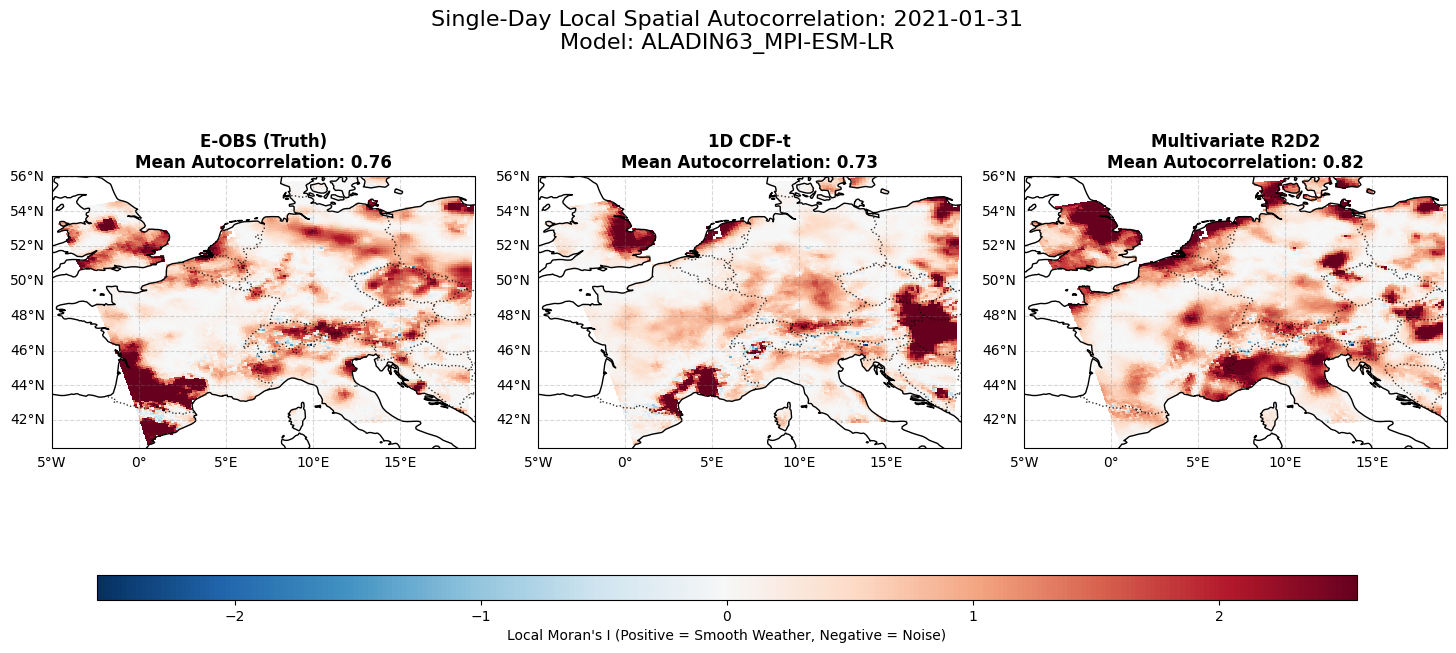

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.ndimage import convolve
import warnings


def calculate_local_morans_i(map_2d, radius=3):
    """
    Calculates the local spatial autocorrelation for a 2D map.
    'radius' defines how many grid cells away the square border reaches.
    A radius of 2 creates an 5x5 neighborhood window.
    """
    # 1. Map statistics (ignoring NaNs)
    x_mean = np.nanmean(map_2d)
    x_var = np.nanvar(map_2d)
    
    # 2. Center the data
    z = map_2d - x_mean
    
    # 3. Define the dynamic neighbor kernel
    kernel_size = (radius * 2) + 1 
    kernel = np.ones((kernel_size, kernel_size))
    
    # Set the exact center pixel to 0 (we only sum neighbors)
    center_idx = radius
    kernel[center_idx, center_idx] = 0
    
    # 4. Safe NaN handling for convolution
    z_filled = np.nan_to_num(z, nan=0.0)
    valid_mask = ~np.isnan(map_2d)
    
    # Count how many valid land neighbors each pixel has within this larger box
    valid_neighbors = convolve(valid_mask.astype(float), kernel, mode='constant', cval=0.0)
    
    # Sum the z-values of all the neighbors
    sum_z_neighbors = convolve(z_filled, kernel, mode='constant', cval=0.0)
    
    # Calculate the average neighbor z-value
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_z_neighbors = sum_z_neighbors / valid_neighbors
        
    # 5. Final Local Moran's I Equation
    local_I = (z / x_var) * mean_z_neighbors
    
    # Re-apply the ocean mask and clean up edges with no neighbors
    local_I[~valid_mask | (valid_neighbors == 0)] = np.nan
    
    return local_I

# =========================================================
# 2. SELECT DAY & EXTRACT MAPS
# =========================================================
test_slice = slice('2018-01-01', '2022-12-31')

r2d2_key = list(R2D2_corrected.keys())[0]  
base_key = r2d2_key.replace("R2D2_", "")
cdft_key = f"CDFt_{base_key}"

print(f"Calculating Single-Day Spatial Autocorrelation for Model: {base_key}")

# Randomly select ONE day
np.random.seed(42) # Remove the number to get a new day every time we run it
ds_obs = Y0_stack.sel(time=test_slice)
random_day_idx = np.random.randint(0, len(ds_obs.time))
target_date = str(ds_obs.time[random_day_idx].values)[:10]
print(f"Selected date: {target_date}")

# Extract 2D maps for that day
dim_y = 'y' if 'y' in Y0_da.dims else 'lat'
dim_x = 'x' if 'x' in Y0_da.dims else 'lon'
ny, nx = Y0_da.sizes[dim_y], Y0_da.sizes[dim_x]

map_obs  = ds_obs.transpose('time', 'points').values[random_day_idx, :].reshape(ny, nx)

# Extract Model Maps and reshape
ds_cdft = CDFt_corrected[cdft_key]['data']['sfcWind'].sel(time=test_slice)
ds_r2d2 = R2D2_corrected[r2d2_key]['data']['sfcWind'].sel(time=test_slice)

dim_y_mod = 'y' if 'y' in ds_cdft.dims else 'rlat'
dim_x_mod = 'x' if 'x' in ds_cdft.dims else 'rlon'

map_cdft = ds_cdft.stack(points=(dim_y_mod, dim_x_mod)).transpose('time', 'points').values[random_day_idx, :].reshape(ny, nx)
map_r2d2 = ds_r2d2.stack(points=(dim_y_mod, dim_x_mod)).transpose('time', 'points').values[random_day_idx, :].reshape(ny, nx)

# =========================================================
# 3. CALCULATE AUTOCORRELATION MAPS
# =========================================================
moran_obs = calculate_local_morans_i(map_obs)
moran_cdft = calculate_local_morans_i(map_cdft)
moran_r2d2 = calculate_local_morans_i(map_r2d2)

# Calculate global averages to show in the titles
mean_I_obs = np.nanmean(moran_obs)
mean_I_cdft = np.nanmean(moran_cdft)
mean_I_r2d2 = np.nanmean(moran_r2d2)

# =========================================================
# 4. PLOT WITH CARTOPY
# =========================================================
# =========================================================
# 4. PLOT WITH CARTOPY
# =========================================================
# Extract 2D coordinate arrays for Cartopy
lons2d = Y0_da['lon'].values if 'lon' in Y0_da.coords else Y0_da['rlon'].values
lats2d = Y0_da['lat'].values if 'lat' in Y0_da.coords else Y0_da['rlat'].values

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': proj})

def format_map(ax, title):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.coastlines(resolution='50m', color='black', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.8)
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = False   
    gl.right_labels = False 
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

# We use a diverging colormap centered at 0
cmap_moran = 'RdBu_r'

# Dynamically set color limits based on the observation data
vmin_I = -np.nanpercentile(np.abs(moran_obs), 95)
vmax_I = np.nanpercentile(np.abs(moran_obs), 95)

im = axes[0].pcolormesh(lons2d, lats2d, moran_obs, cmap=cmap_moran, vmin=vmin_I, vmax=vmax_I, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[0], f"E-OBS (Truth)\nMean Autocorrelation: {mean_I_obs:.2f}")

axes[1].pcolormesh(lons2d, lats2d, moran_cdft, cmap=cmap_moran, vmin=vmin_I, vmax=vmax_I, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[1], f"1D CDF-t\nMean Autocorrelation: {mean_I_cdft:.2f}")

axes[2].pcolormesh(lons2d, lats2d, moran_r2d2, cmap=cmap_moran, vmin=vmin_I, vmax=vmax_I, transform=ccrs.PlateCarree(), shading='auto')
format_map(axes[2], f"Multivariate R2D2\nMean Autocorrelation: {mean_I_r2d2:.2f}")

cbar_ax = fig.add_axes([0.15, -0.08, 0.7, 0.05])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label="Local Moran's I (Positive = Smooth Weather, Negative = Noise)")

plt.suptitle(f"Single-Day Local Spatial Autocorrelation: {target_date}\nModel: {base_key}", fontsize=16, y=1.1)
plt.subplots_adjust(wspace=0.15)
plt.show()

### Forensic plots

Max Wind Pixel

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

save_dir_forensics = "/userdata/yangmi/MasterThesis/Figures/Bias_Correction_Validation"

def forensic_max_wind_failure(obs_full, raw_full, bc_full, model_name, save_dir):
    print(f"Locating Worst Max-Wind Pixel for {model_name}...")

    # =========================================================
    # 1. FIND THE WORST MAX-WIND PIXEL
    # =========================================================
    train_slice = slice("1980-01-01", "2017-12-31")
    test_slice  = slice("2018-01-01", "2022-12-31")
    
    # Isolate test period
    obs_test = obs_full.sel(time=test_slice)
    raw_test = raw_full.sel(time=test_slice)
    bc_test  = bc_full.sel(time=test_slice)

    # Calculate the Temporal MAXIMUM for the test period
    obs_max = obs_test.max('time', skipna=True)
    raw_max = raw_test.max('time', skipna=True)
    bc_max  = bc_test.max('time', skipna=True)
    
    # Calculate Biases for Extreme Winds in the test period
    bias_raw = raw_max - obs_max
    bias_bc  = bc_max - obs_max
    
    # Calculate Bias Alteration (Positive = Bias Got Worse)
    diff_abs_bias = abs(bias_bc) - abs(bias_raw)
    
    # Find the Array Index of the maximum penalty safely
    flat_idx = int(diff_abs_bias.fillna(-999).argmax(skipna=True).compute())
    idx_tuple = np.unravel_index(flat_idx, diff_abs_bias.shape)
    
    dim_y, dim_x = diff_abs_bias.dims[0], diff_abs_bias.dims[1]
    isel_kwargs = {dim_y: idx_tuple[0], dim_x: idx_tuple[1]}
    
    max_penalty = float(diff_abs_bias.isel(**isel_kwargs).compute())
    
    # Extract Lat/Lon safely
    if 'lat' in obs_full.coords and 'lon' in obs_full.coords:
        if obs_full['lat'].ndim == 2: # 2D coords
            lat_label = float(obs_full['lat'].isel(**isel_kwargs).values)
            lon_label = float(obs_full['lon'].isel(**isel_kwargs).values)
        else: # 1D coords
            lat_label = float(obs_full['lat'].isel({dim_y: idx_tuple[0]}).values)
            lon_label = float(obs_full['lon'].isel({dim_x: idx_tuple[1]}).values)
    else:
        lat_label = float(obs_full[dim_y].isel({dim_y: idx_tuple[0]}).values)
        lon_label = float(obs_full[dim_x].isel({dim_x: idx_tuple[1]}).values)

    print(f"   Found Pixel -> Lat {lat_label:.2f}, Lon {lon_label:.2f}")
    print(f"   -> True Max Wind in Test Period: {float(obs_max.isel(**isel_kwargs).compute()):.2f} m/s")
    print(f"   -> Corrected Max in Test Period: {float(bc_max.isel(**isel_kwargs).compute()):.2f} m/s")
    print(f"   -> Original Bias: {float(bias_raw.isel(**isel_kwargs).compute()):.2f} m/s")
    print(f"   -> Corrected Bias:{float(bias_bc.isel(**isel_kwargs).compute()):.2f} m/s")
    print(f"   -> Difference in Absolute Bias:       +{max_penalty:.2f} m/s")

    # =========================================================
    # 2. EXTRACT TIME SERIES FOR THE PIXEL
    # =========================================================
    print(f"\n Extracting Time Series & Running Forensics...")
    
    # Extract the Xarray pixel
    pt_obs = obs_full.isel(**isel_kwargs)
    pt_raw = raw_full.isel(**isel_kwargs)
    pt_bc  = bc_full.isel(**isel_kwargs)
    
    # Safe converter function to bypass Pandas cftime bugs
    # def build_safe_df(da_obs, da_raw, da_bc):
    #     df = pd.DataFrame({
    #         'obs': da_obs.values.flatten(),
    #         'raw': da_raw.values.flatten(),
    #         'bc':  da_bc.values.flatten()
    #     })
    #     # Extract pure month integers
    #     df['month'] = da_obs['time'].dt.month.values

    #     # Convert index to standard Python dates
    #     dates = []
    #     for t in da_obs['time'].values:
    #         if hasattr(t, 'year'):
    #             dates.append(pd.Timestamp(t.year, t.month, t.day))
    #         else:
    #             dates.append(pd.to_datetime(t))
    #     df.index = dates
    #     return df.dropna()
    
    def build_safe_df(da_obs, da_raw, da_bc):
        def get_dates(da):
            dates = []
            for t in da['time'].values:
                # Force strictly to YYYY-MM-DD (midnight) regardless of cftime or numpy types
                if hasattr(t, 'year'):
                    dates.append(pd.Timestamp(year=t.year, month=t.month, day=t.day))
                else:
                    dt = pd.to_datetime(t)
                    dates.append(pd.Timestamp(year=dt.year, month=dt.month, day=dt.day))
            return dates
        
        # Build independent series 
        s_obs = pd.Series(da_obs.values.flatten(), index=get_dates(da_obs), name='obs')
        s_raw = pd.Series(da_raw.values.flatten(), index=get_dates(da_raw), name='raw')
        s_bc  = pd.Series(da_bc.values.flatten(),  index=get_dates(da_bc),  name='bc')
        
        # Pandas auto-aligns them by date (ignoring hours) and drops mismatches!
        # sort=True is added to silence the Pandas warning we saw
        df = pd.concat([s_obs, s_raw, s_bc], axis=1, sort=True)
        df['month'] = df.index.month
        return df.dropna()
    
    df_train = build_safe_df(pt_obs.sel(time=train_slice), pt_raw.sel(time=train_slice), pt_bc.sel(time=train_slice))
    df_test  = build_safe_df(pt_obs.sel(time=test_slice),  pt_raw.sel(time=test_slice),  pt_bc.sel(time=test_slice))

    if df_train.empty or df_test.empty:
        raise ValueError("DataFrames are empty! The time slicing failed.")

    df = pd.concat([df_train, df_test])
    df['raw_bias'] = df['raw'] - df['obs']
    df['bc_bias']  = df['bc'] - df['obs']

    # =========================================================
    # 3. BUILD THE 6-PANEL FORENSIC DASHBOARD
    # =========================================================
    fig, axes = plt.subplots(3, 2, figsize=(22, 30), constrained_layout=True)
    max_val = max(df_test['raw'].max(), df_test['obs'].max(), df_train['raw'].max(), df_train['obs'].max())
    bins = np.linspace(0, max_val, 60)

    # --- PANEL 1: Histogram (Training Period) ---
    ax_h1 = axes[0, 0]
    ax_h1.set_yscale('log')
    ax_h1.hist(df_train['raw'], bins=bins, density=True, alpha=0.5, color='red', label=f"Raw Train (Max: {df_train['raw'].max():.2f})")
    ax_h1.hist(df_train['obs'], bins=bins, density=True, histtype='step', linewidth=3, color='black', label=f"Obs Train (Max: {df_train['obs'].max():.2f})")
    ax_h1.hist(df_train['bc'], bins=bins, density=True, alpha=0.5, color='blue', label=f"Corr Train (Max: {df_train['bc'].max():.2f})")
    ax_h1.set_title("1. Training period (1980-2017)", fontweight='bold', fontsize=14)
    ax_h1.set_ylabel("Log Density"); ax_h1.set_xlabel("Wind Speed (m/s)")
    ax_h1.legend(); ax_h1.grid(True, alpha=0.3)

    # --- PANEL 2: Histogram (Test Period Breakdown) ---
    ax_h2 = axes[0, 1]
    ax_h2.set_yscale('log')
    ax_h2.hist(df_test['raw'], bins=bins, density=True, alpha=0.3, color='red', label=f"Raw Test (Max: {df_test['raw'].max():.2f})")
    ax_h2.hist(df_test['bc'],  bins=bins, density=True, alpha=0.5, color='blue', label=f"Corr Test (Max: {df_test['bc'].max():.2f})")
    ax_h2.hist(df_test['obs'], bins=bins, density=True, histtype='step', linewidth=3, color='black', label=f"Obs Test (Max: {df_test['obs'].max():.2f})")
    ax_h2.set_title("2. Test period (2018-2022)", fontweight='bold', fontsize=14)
    ax_h2.set_ylabel("Log Density"); ax_h2.set_xlabel("Wind Speed (m/s)")
    ax_h2.legend(); ax_h2.grid(True, alpha=0.3)

    # --- PANEL 3: ROLLING BIAS (Stationarity Check) ---
    ax_roll = axes[1, 0]
    rolling_bias = df['raw_bias'].rolling(window=365, center=True).mean()
    
    ax_roll.plot(rolling_bias.index, rolling_bias, color='red', linewidth=2, label='Raw Model Bias (365-day rolling mean)')
    ax_roll.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax_roll.axvline(pd.to_datetime('2018-01-01'), color='green', linestyle=':', linewidth=3, label='Train/Test Split')
    
    clean_roll = rolling_bias.dropna()
    if len(clean_roll) > 0:
        x_num = np.arange(len(clean_roll))
        z = np.polyfit(x_num, clean_roll, 1)
        p = np.poly1d(z)
        ax_roll.plot(clean_roll.index, p(x_num), color='darkred', linestyle='-.', label=f'Bias Trend (slope: {z[0]*365:.4f}/yr)')

    ax_roll.set_title("3. Temporal Stationarity of Raw Bias", fontweight='bold', fontsize=14)
    ax_roll.set_ylabel("Bias (m/s) [Positive = Model Overestimates]"); ax_roll.legend(); ax_roll.grid(True, alpha=0.4)

    # --- PANEL 4: Q-Q PLOT (Distribution Shape Shift) ---
    ax_qq = axes[1, 1]
    quantiles = np.linspace(0.01, 0.99, 100)
    
    q_obs_tr, q_raw_tr = np.quantile(df_train['obs'], quantiles), np.quantile(df_train['raw'], quantiles)
    q_obs_te, q_raw_te = np.quantile(df_test['obs'], quantiles), np.quantile(df_test['raw'], quantiles)
    
    ax_qq.scatter(q_obs_tr, q_raw_tr, color='gray', alpha=0.5, label='Train Period (1980-2017)')
    ax_qq.scatter(q_obs_te, q_raw_te, color='red', marker='x', s=50, label='Test Period (2018-2022)')
    
    max_qq = max(ax_qq.get_xlim()[1], ax_qq.get_ylim()[1])
    ax_qq.plot([0, max_qq], [0, max_qq], color='black', linestyle='--')
    
    ax_qq.set_title("4. Quantile-Quantile Shift", fontweight='bold', fontsize=14)
    ax_qq.set_xlabel("Observation Quantiles (m/s)"); ax_qq.set_ylabel("Raw Model Quantiles (m/s)")
    ax_qq.legend(); ax_qq.grid(True, alpha=0.4)

    # --- PANEL 5: SEASONAL ERROR BREAKDOWN ---
    ax_seas = axes[2, 0]
    def get_seasonal_mae(df_subset):
        df_subset['season'] = df_subset['month'] % 12 // 3 + 1
        season_map = {1: 'DJF', 2: 'MAM', 3: 'JJA', 4: 'SON'}
        df_subset['season'] = df_subset['season'].map(season_map)
        return df_subset.groupby('season').apply(lambda x: np.mean(np.abs(x['raw'] - x['obs'])))
        
    mae_tr = get_seasonal_mae(df_train.copy())
    mae_te = get_seasonal_mae(df_test.copy())
    
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    x_pos = np.arange(len(seasons))
    width = 0.35
    
    ax_seas.bar(x_pos - width/2, [mae_tr.get(s, 0) for s in seasons], width, label='Train MAE', color='gray', alpha=0.7)
    ax_seas.bar(x_pos + width/2, [mae_te.get(s, 0) for s in seasons], width, label='Test MAE', color='red', alpha=0.7)
    
    ax_seas.set_title("5. Seasonal Mean Absolute Error Shift", fontweight='bold', fontsize=14)
    ax_seas.set_xticks(x_pos); ax_seas.set_xticklabels(seasons)
    ax_seas.set_ylabel("Mean Absolute Error (m/s)"); ax_seas.legend(); ax_seas.grid(axis='y', alpha=0.4)

    # # --- PANEL 6: EXTRAPOLATION CHECK (The Tails) ---
    # ax_ecdf = axes[2, 1]
    # def ecdf(data):
    #     x = np.sort(data)
    #     y = np.arange(1, len(x) + 1) / len(x)
    #     return x, y
        
    # x_tr, y_tr = ecdf(df_train['raw'])
    # x_te, y_te = ecdf(df_test['raw'])
    
    # ax_ecdf.plot(x_tr, y_tr, color='gray', linewidth=2, label='Train Raw CDF')
    # ax_ecdf.plot(x_te, y_te, color='red', linewidth=2, linestyle='--', label='Test Raw CDF')
    
    # max_train_val = df_train['raw'].max()
    # max_test_val  = df_test['raw'].max()
    # if max_test_val > max_train_val:
    #     ax_ecdf.axvspan(max_train_val, max_test_val, color='orange', alpha=0.2, label='Unseen Test Extremes')
    
    # ax_ecdf.set_title("6. Extrapolation at the Extremes (eCDF)", fontweight='bold', fontsize=14)
    # ax_ecdf.set_xlabel("Wind Speed (m/s)"); ax_ecdf.set_ylabel("Cumulative Probability")
    # ax_ecdf.set_ylim(0.90, 1.0) # Zoomed in on top 10%
    # ax_ecdf.legend(); ax_ecdf.grid(True, alpha=0.4)

    # --- PANEL 6: MONTHLY MAXIMUM TIME SERIES (1980-2022) ---
    ax_ts = axes[2, 1]
    
    # Resample the entire dataset to find the maximum wind speed for each month
    # Note: 'ME' (Month End) is the modern Pandas standard for monthly resampling
    monthly_max = df[['obs', 'raw', 'bc']].resample('ME').max()
    
    # Plot the time series
    ax_ts.plot(monthly_max.index, monthly_max['raw'], color='red', alpha=0.5, label='Raw Monthly Max')
    ax_ts.plot(monthly_max.index, monthly_max['bc'], color='blue', alpha=0.7, label='Corr Monthly Max')
    ax_ts.plot(monthly_max.index, monthly_max['obs'], color='black', alpha=0.8, linewidth=1.5, label='Obs Monthly Max')
    
    # Highlight the split between the Training and Testing periods
    ax_ts.axvline(pd.to_datetime('2018-01-01'), color='green', linestyle=':', linewidth=3, label='Train/Test Split')
    
    ax_ts.set_title("6. Monthly Maximum Wind Speed (1980-2022)", fontweight='bold', fontsize=14)
    ax_ts.set_xlabel("Time")
    ax_ts.set_ylabel("Max Wind Speed (m/s)")
    ax_ts.legend(loc='upper left')
    ax_ts.grid(True, alpha=0.4) 

    # Calculate values for the title
    val_true = float(obs_max.isel(**isel_kwargs).compute())
    val_corr = float(bc_max.isel(**isel_kwargs).compute())
    val_bias_orig = float(bias_raw.isel(**isel_kwargs).compute())
    val_bias_corr = float(bias_bc.isel(**isel_kwargs).compute())

    title_text = (
            f"Forensic Dashboard: Max-Wind Failure ({model_name})\n\n"
            f"Found Pixel -> Lat {lat_label:.2f}, Lon {lon_label:.2f}\n"
            f"True Max Wind in Test Period: {val_true:.2f} m/s  |  Corrected Max in Test Period: {val_corr:.2f} m/s\n"
            f"Original Bias: {val_bias_orig:.2f} m/s  |  Corrected Bias: {val_bias_corr:.2f} m/s\n"
            f"Difference in Absolute Bias: +{max_penalty:.2f} m/s"
        )
    
    fig.suptitle(title_text, fontsize=20, fontweight='bold', y=1.06)
    #fig.suptitle(f"Forensic Dashboard: Max-Wind Failure ({model_name})\nLat: {lat_label:.2f}, Lon: {lon_label:.2f}", fontsize=24, fontweight='bold', y=1.02)
    #plt.show()
    filename = os.path.join(save_dir, f"Forensic_Fail_MaxWind_R2D2_{model_name}.png")
    fig.savefig(filename, dpi=120, bbox_inches='tight')
    plt.close(fig)
    print(f"   Saved: {filename}")

# =========================================================
# RUN IT
# =========================================================
# test_model_key = list(corrected_datasets.keys())[0]
# base_key = test_model_key.replace("sfcWind_R2D2-monthly-train-test_corrected_", "").replace(".nc", "")
# X1_full = standardize_data(rcm_datasets[base_key]['data']['sfcWind'], Y0_da)
# Z1_full = standardize_data(monthly_corrected_datasets[test_model_key]['sfcWind'], Y0_da)
# forensic_max_wind_failure(Y0_da, X1_full, Z1_full, base_key)

Min Wind Pixel

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def forensic_min_wind_failure(obs_full, raw_full, bc_full, model_name, save_dir):
    print(f"Locating Worst Min-Wind Pixel for {model_name}...")

    # =========================================================
    # 1. FIND THE WORST MIN-WIND PIXEL
    # =========================================================
    train_slice = slice("1980-01-01", "2017-12-31")
    test_slice  = slice("2018-01-01", "2022-12-31")
    
    # Isolate test period
    obs_test = obs_full.sel(time=test_slice)
    raw_test = raw_full.sel(time=test_slice)
    bc_test  = bc_full.sel(time=test_slice)

    # Calculate the Temporal MINIMUM for the test period
    obs_min = obs_test.min('time', skipna=True)
    raw_min = raw_test.min('time', skipna=True)
    bc_min  = bc_test.min('time', skipna=True)
    
    # Calculate Biases for Extreme Low Winds in the test period
    bias_raw = raw_min - obs_min
    bias_bc  = bc_min - obs_min
    
    # Calculate Bias Alteration (Positive = Bias Got Worse)
    diff_abs_bias = abs(bias_bc) - abs(bias_raw)
    
    # Find the Array Index of the maximum penalty safely
    flat_idx = int(diff_abs_bias.fillna(-999).argmax(skipna=True).compute())
    idx_tuple = np.unravel_index(flat_idx, diff_abs_bias.shape)
    
    dim_y, dim_x = diff_abs_bias.dims[0], diff_abs_bias.dims[1]
    isel_kwargs = {dim_y: idx_tuple[0], dim_x: idx_tuple[1]}
    
    max_penalty = float(diff_abs_bias.isel(**isel_kwargs).compute())
    
    # Extract Lat/Lon safely
    if 'lat' in obs_full.coords and 'lon' in obs_full.coords:
        if obs_full['lat'].ndim == 2: # 2D coords
            lat_label = float(obs_full['lat'].isel(**isel_kwargs).values)
            lon_label = float(obs_full['lon'].isel(**isel_kwargs).values)
        else: # 1D coords
            lat_label = float(obs_full['lat'].isel({dim_y: idx_tuple[0]}).values)
            lon_label = float(obs_full['lon'].isel({dim_x: idx_tuple[1]}).values)
    else:
        lat_label = float(obs_full[dim_y].isel({dim_y: idx_tuple[0]}).values)
        lon_label = float(obs_full[dim_x].isel({dim_x: idx_tuple[1]}).values)

    print(f"   Found Pixel -> Lat {lat_label:.2f}, Lon {lon_label:.2f}")
    print(f"   -> True Min Wind in Test Period: {float(obs_min.isel(**isel_kwargs).compute()):.2f} m/s")
    print(f"   -> Corrected Min in Test Period: {float(bc_min.isel(**isel_kwargs).compute()):.2f} m/s")
    print(f"   -> Difference in Absolute Bias:  +{max_penalty:.2f} m/s")

    # =========================================================
    # 2. EXTRACT TIME SERIES FOR THE PIXEL
    # =========================================================
    print(f"\n Extracting Time Series & Running Forensics...")
    
    # Extract the Xarray pixel
    pt_obs = obs_full.isel(**isel_kwargs)
    pt_raw = raw_full.isel(**isel_kwargs)
    pt_bc  = bc_full.isel(**isel_kwargs)

    # Safe converter function to bypass Pandas cftime bugs
    # def build_safe_df(da_obs, da_raw, da_bc):
    #     df = pd.DataFrame({
    #         'obs': da_obs.values.flatten(),
    #         'raw': da_raw.values.flatten(),
    #         'bc':  da_bc.values.flatten()
    #     })
    #     # Extract pure month integers
    #     df['month'] = da_obs['time'].dt.month.values

    #     # Convert index to standard Python dates
    #     dates = []
    #     for t in da_obs['time'].values:
    #         if hasattr(t, 'year'):
    #             dates.append(pd.Timestamp(t.year, t.month, t.day))
    #         else:
    #             dates.append(pd.to_datetime(t))
    #     df.index = dates
    #     return df.dropna()
    
    def build_safe_df(da_obs, da_raw, da_bc):
        def get_dates(da):
            dates = []
            for t in da['time'].values:
                # Force strictly to YYYY-MM-DD (midnight) regardless of cftime or numpy types
                if hasattr(t, 'year'):
                    dates.append(pd.Timestamp(year=t.year, month=t.month, day=t.day))
                else:
                    dt = pd.to_datetime(t)
                    dates.append(pd.Timestamp(year=dt.year, month=dt.month, day=dt.day))
            return dates
        
        # Build independent series 
        s_obs = pd.Series(da_obs.values.flatten(), index=get_dates(da_obs), name='obs')
        s_raw = pd.Series(da_raw.values.flatten(), index=get_dates(da_raw), name='raw')
        s_bc  = pd.Series(da_bc.values.flatten(),  index=get_dates(da_bc),  name='bc')
        
        # Pandas auto-aligns them by date (ignoring hours) and drops mismatches!
        # sort=True is added to silence the Pandas warning we saw
        df = pd.concat([s_obs, s_raw, s_bc], axis=1, sort=True)
        df['month'] = df.index.month
        return df.dropna()

    df_train = build_safe_df(pt_obs.sel(time=train_slice), pt_raw.sel(time=train_slice), pt_bc.sel(time=train_slice))
    df_test  = build_safe_df(pt_obs.sel(time=test_slice),  pt_raw.sel(time=test_slice),  pt_bc.sel(time=test_slice))

    if df_train.empty or df_test.empty:
        raise ValueError("DataFrames are empty! The time slicing failed.")

    df = pd.concat([df_train, df_test])
    df['raw_bias'] = df['raw'] - df['obs']
    df['bc_bias']  = df['bc'] - df['obs']

    # =========================================================
    # 3. BUILD THE 6-PANEL FORENSIC DASHBOARD
    # =========================================================
    fig, axes = plt.subplots(3, 2, figsize=(22, 30), constrained_layout=True)
    max_val = max(df_test['raw'].max(), df_test['obs'].max(), df_train['raw'].max(), df_train['obs'].max())
    bins = np.linspace(0, max_val, 60)

    # --- PANEL 1: Histogram (Training Period) ---
    ax_h1 = axes[0, 0]
    ax_h1.set_yscale('log')
    # Updated to show .min() instead of .max() in the legend
    ax_h1.hist(df_train['raw'], bins=bins, density=True, alpha=0.5, color='red', label=f"Raw Train (Min: {df_train['raw'].min():.2f})")
    ax_h1.hist(df_train['obs'], bins=bins, density=True, histtype='step', linewidth=3, color='black', label=f"Obs Train (Min: {df_train['obs'].min():.2f})")
    ax_h1.hist(df_train['bc'], bins=bins, density=True, alpha=0.5, color='blue', label=f"Corr Train (Min: {df_train['bc'].min():.2f})")
    ax_h1.set_title("1. Training period (1980-2017)", fontweight='bold', fontsize=14)
    ax_h1.set_ylabel("Log Density"); ax_h1.set_xlabel("Wind Speed (m/s)")
    ax_h1.legend(); ax_h1.grid(True, alpha=0.3)

    # --- PANEL 2: Histogram (Test Period Breakdown) ---
    ax_h2 = axes[0, 1]
    ax_h2.set_yscale('log')
    ax_h2.hist(df_test['raw'], bins=bins, density=True, alpha=0.3, color='red', label=f"Raw Test (Min: {df_test['raw'].min():.2f})")
    ax_h2.hist(df_test['bc'],  bins=bins, density=True, alpha=0.5, color='blue', label=f"Corr Test (Min: {df_test['bc'].min():.2f})")
    ax_h2.hist(df_test['obs'], bins=bins, density=True, histtype='step', linewidth=3, color='black', label=f"Obs Test (Min: {df_test['obs'].min():.2f})")
    ax_h2.set_title("2. Test period (2018-2022)", fontweight='bold', fontsize=14)
    ax_h2.set_ylabel("Log Density"); ax_h2.set_xlabel("Wind Speed (m/s)")
    ax_h2.legend(); ax_h2.grid(True, alpha=0.3)

    # --- PANEL 3: ROLLING BIAS (Stationarity Check) ---
    ax_roll = axes[1, 0]
    rolling_bias = df['raw_bias'].rolling(window=365, center=True).mean()
    
    ax_roll.plot(rolling_bias.index, rolling_bias, color='red', linewidth=2, label='Raw Model Bias (365-day rolling mean)')
    ax_roll.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax_roll.axvline(pd.to_datetime('2018-01-01'), color='green', linestyle=':', linewidth=3, label='Train/Test Split')
    
    clean_roll = rolling_bias.dropna()
    if len(clean_roll) > 0:
        x_num = np.arange(len(clean_roll))
        z = np.polyfit(x_num, clean_roll, 1)
        p = np.poly1d(z)
        ax_roll.plot(clean_roll.index, p(x_num), color='darkred', linestyle='-.', label=f'Bias Trend (slope: {z[0]*365:.4f}/yr)')

    ax_roll.set_title("3. Temporal Stationarity of Raw Bias", fontweight='bold', fontsize=14)
    ax_roll.set_ylabel("Bias (m/s) [Positive = Model Overestimates]"); ax_roll.legend(); ax_roll.grid(True, alpha=0.4)

    # --- PANEL 4: Q-Q PLOT (Distribution Shape Shift) ---
    ax_qq = axes[1, 1]
    quantiles = np.linspace(0.01, 0.99, 100)
    
    q_obs_tr, q_raw_tr = np.quantile(df_train['obs'], quantiles), np.quantile(df_train['raw'], quantiles)
    q_obs_te, q_raw_te = np.quantile(df_test['obs'], quantiles), np.quantile(df_test['raw'], quantiles)
    
    ax_qq.scatter(q_obs_tr, q_raw_tr, color='gray', alpha=0.5, label='Train Period (1980-2017)')
    ax_qq.scatter(q_obs_te, q_raw_te, color='red', marker='x', s=50, label='Test Period (2018-2022)')
    
    max_qq = max(ax_qq.get_xlim()[1], ax_qq.get_ylim()[1])
    ax_qq.plot([0, max_qq], [0, max_qq], color='black', linestyle='--')
    
    ax_qq.set_title("4. Quantile-Quantile Shift", fontweight='bold', fontsize=14)
    ax_qq.set_xlabel("Observation Quantiles (m/s)"); ax_qq.set_ylabel("Raw Model Quantiles (m/s)")
    ax_qq.legend(); ax_qq.grid(True, alpha=0.4)

    # --- PANEL 5: SEASONAL ERROR BREAKDOWN ---
    ax_seas = axes[2, 0]
    def get_seasonal_mae(df_subset):
        df_subset['season'] = df_subset['month'] % 12 // 3 + 1
        season_map = {1: 'DJF', 2: 'MAM', 3: 'JJA', 4: 'SON'}
        df_subset['season'] = df_subset['season'].map(season_map)
        return df_subset.groupby('season').apply(lambda x: np.mean(np.abs(x['raw'] - x['obs'])))
        
    mae_tr = get_seasonal_mae(df_train.copy())
    mae_te = get_seasonal_mae(df_test.copy())
    
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    x_pos = np.arange(len(seasons))
    width = 0.35
    
    ax_seas.bar(x_pos - width/2, [mae_tr.get(s, 0) for s in seasons], width, label='Train MAE', color='gray', alpha=0.7)
    ax_seas.bar(x_pos + width/2, [mae_te.get(s, 0) for s in seasons], width, label='Test MAE', color='red', alpha=0.7)
    
    ax_seas.set_title("5. Seasonal Mean Absolute Error Shift", fontweight='bold', fontsize=14)
    ax_seas.set_xticks(x_pos); ax_seas.set_xticklabels(seasons)
    ax_seas.set_ylabel("Mean Absolute Error (m/s)"); ax_seas.legend(); ax_seas.grid(axis='y', alpha=0.4)

    # --- PANEL 6: MONTHLY MINIMUM TIME SERIES (1980-2022) ---
    ax_ts = axes[2, 1]
    
    # Resample the entire dataset to find the MINIMUM wind speed for each month
    monthly_min = df[['obs', 'raw', 'bc']].resample('ME').min()
    
    # Plot the time series
    ax_ts.plot(monthly_min.index, monthly_min['raw'], color='red', alpha=0.5, label='Raw Monthly Min')
    ax_ts.plot(monthly_min.index, monthly_min['bc'], color='blue', alpha=0.7, label='Corr Monthly Min')
    ax_ts.plot(monthly_min.index, monthly_min['obs'], color='black', alpha=0.8, linewidth=1.5, label='Obs Monthly Min')
    
    # Highlight the split between the Training and Testing periods
    ax_ts.axvline(pd.to_datetime('2018-01-01'), color='green', linestyle=':', linewidth=3, label='Train/Test Split')
    
    ax_ts.set_title("6. Monthly Minimum Wind Speed (1980-2022)", fontweight='bold', fontsize=14)
    ax_ts.set_xlabel("Time")
    ax_ts.set_ylabel("Min Wind Speed (m/s)")
    ax_ts.legend(loc='upper left')
    ax_ts.grid(True, alpha=0.4) 

    # Multi-line dynamic title
    val_true = float(obs_min.isel(**isel_kwargs).compute())
    val_corr = float(bc_min.isel(**isel_kwargs).compute())
    val_bias_orig = float(bias_raw.isel(**isel_kwargs).compute())
    val_bias_corr = float(bias_bc.isel(**isel_kwargs).compute())
    title_text = (
        f"Forensic Dashboard: Min-Wind Failure ({model_name})\n\n"
        f"Found Pixel -> Lat {lat_label:.2f}, Lon {lon_label:.2f}\n"
        f"True Min Wind in Test Period: {val_true:.2f} m/s  |  Corrected Min in Test Period: {val_corr:.2f} m/s\n"
        f"Original Bias: {val_bias_orig:.2f} m/s  |  Corrected Bias: {val_bias_corr:.2f} m/s\n"
        f"Difference in Absolute Bias: +{max_penalty:.2f} m/s"
    )
    fig.suptitle(title_text, fontsize=20, fontweight='bold', y=1.06)
    #fig.suptitle(f"Forensic Dashboard: Min-Wind Failure ({model_name})\nLat: {lat_label:.2f}, Lon: {lon_label:.2f}", fontsize=24, fontweight='bold', y=1.02)
    #plt.show()
    filename = os.path.join(save_dir, f"Forensic_Fail_MinWind_{model_name}.png")
    fig.savefig(filename, dpi=120, bbox_inches='tight')
    plt.close(fig)
    print(f"   ✅ Saved: {filename}")

# =========================================================
# RUN IT
# =========================================================
# test_model_key = list(monthly_corrected_datasets.keys())[0]
# base_key = test_model_key.replace("sfcWind_CDFt-monthly-train-test_corrected_", "").replace(".nc", "")
# X1_full = standardize_data(rcm_datasets[base_key]['data']['sfcWind'], Y0_da)
# Z1_full = standardize_data(monthly_corrected_datasets[test_model_key]['sfcWind'], Y0_da)
# forensic_min_wind_failure(Y0_da, X1_full, Z1_full, base_key)

In [ ]:
for key, bc_info in monthly_corrected_datasets.items():
    print(f"\n==================================================")
    print(f"Processing Model Dataset: {key}")
    
    try:
        # Robustly extract the base model name to look up raw data
        base_key = key.replace("sfcWind_CDFt-monthly-train-test_corrected_", "").replace(".nc", "")
        # Fallback if saved with a different prefix
        base_key = base_key.replace("sfcWind_CDFt-monthly_corrected_", "")
        
        # Load Raw and Corrected DataArrays
        ds_raw_full = rcm_datasets[base_key]['data']['sfcWind']
        
        if isinstance(bc_info, dict):
            ds_bc_full = bc_info['data']['sfcWind']
        else:
            ds_bc_full = bc_info['sfcWind']
        
        # Standardize geographic alignment with Obs
        X1_full = standardize_data(ds_raw_full, Y0_da)
        Z1_full = standardize_data(ds_bc_full, Y0_da)
        
        # Execute Max Wind Forensic
        forensic_max_wind_failure(Y0_da, X1_full, Z1_full, base_key, save_dir_forensics)
        
        # Execute Min Wind Forensic
        forensic_min_wind_failure(Y0_da, X1_full, Z1_full, base_key, save_dir_forensics)
        
    except Exception as e:
        print(f"   ERROR processing {key}: {e}")

print("\n Batch processing complete! Check your output directory for the 16 Forensic Dashboards.")